# H08：共同资格筛选与可评价样本评价

**当前评价口径（2026-09-25）**：固定原推理名单后，仅在有效标签样本上计算命中率、Recall、F1及Lift；同时报告有效数量、剔除数与覆盖率，不补选。见[独立复算章节](#h08-evaluable-protocol)。

当前复算通过：25种方法×151日的3,775个原名单完全一致。浅树事件模型的开发段日均命中率为36.53%（日频）/37.13%（全部L2），历史复核为39.05%/40.99%。这里只更换评价分母，未重训；没有新的显著性或模型采用结论。

以下是2026-09-24冻结实验的历史结果，旧上下界不再作为当前主评价。

本 Notebook 执行[H08运行前方案](#h08-protocol-20260924)。
采用P日状态在22:00可用的假设，T日09:00决策。历史接收时间及版本尚无证据，结果仅适用于
这个条件情景；不能声称已排除T日新增ST/停牌，或已通过实际时点验证。
原始标签排名、39列特征、K=50和H07的20配置不变。所有排除、未知标签和失败检查保留。
旧的T日事后诊断与源修复证据保存在卷宗所列归档，不作为本轮资格输入。

已执行结果：共同候选1,062,525行，719个未知标签；20配置完成160次拟合与151日全池预测。
浅树事件概率日频/全部L2的开发Precision下界为36.46%/37.04%，历史复核为38.94%/40.94%。
两分类器主比较的95%包络均跨零；2,577份输入及全部模型、名单和验证结果已冻结。
完整结论与限制见卷宗H08，严格历史可用性依旧未通过。

2026-09-24新增[两阶段筛选验证](#h08-two-stage-protocol)：盘前停牌筛选后，在14:30按已完成分钟的累计成交量再次筛选。新增章节已独立执行；原模型及其输出未改。T日最终停牌表的事后诊断保留1,062,183行、380个未知标签；这不是已验证的盘前名单。

## 证据说明索引

以下说明于 2026-09-24 从同主题 README 整理迁入，保存各节标注日期的方案、事实与当时解释；迁移不是新的运行或事前登记。当前假设、状态、结论和决定由 [README](README.md) 拥有。历史归档中的源码、Notebook、输入、验收快照和保留期继续有效，精确复现按对应归档说明执行。

- [H08 2026-09-23 共同资格规则与严格验收](#h08-strict-protocol)
- [H08 2026-09-24 前日状态条件研究的冻结方案](#h08-protocol-20260924)
- [H08 2026-09-23 修复前状态源与窗口核查](#h08-source-audit-20260923)
- [2026-09-23 用户授权的历史股票列表修复](#stock-basic-repair-2026-09-23)
- [H08 2026-09-24 共同资格面板、重训结果与归档](#h08-evidence-20260924)
- [H08 2026-09-24 条件重训的精确恢复](#h08-reproduce-20260924)

- [两阶段筛选：盘前停牌与14:30累计成交量](#h08-two-stage-protocol)

- [2026-09-25 当前主评价：固定名单后的可评价样本](#h08-evaluable-protocol)


## 1. 固定方法与环境
开发134日及历史复核17日都已消费，没有独立最终验证集。
月首08:00扩展历史拟合，09:00模型就绪；输入可用时间为情景假设。
同一股票日资格适用于所有学习器及日频/L2。统计门槛沿用H07，不追加调参。

In [1]:
import hashlib
import importlib.metadata
import json
import math
import re
import shutil
import subprocess
import tarfile
import tempfile
import time
import warnings
from collections.abc import Sequence
from datetime import UTC, date, datetime
from datetime import time as wall_time
from pathlib import Path
from typing import NamedTuple, TypedDict

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)
from threadpoolctl import threadpool_limits

from src.config.model_config import MissingConfig, PreprocessingConfig
from src.training.engines.preprocessing import FittedPreprocessor
from src.utils import table_ops
from src.utils.datetime_utils import DateTimeUtils
from src.utils.filesystem import FileSystem

source_root = Path.cwd()
assert (source_root / "research/subscription-training/README.md").is_file()
prior = Path(
    "/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2"
)
storage = Path("/home/wsw/app/data")
supplement = Path(
    "/home/wsw/app/research-evidence/subscription-status-supplement-2026-09-24-h96prkye"
)
previous_audit = Path(
    "/home/wsw/app/research-evidence/subscription-universe-2026-09-23-q5afkh1y"
)
previous_event = Path(
    "/home/wsw/app/research-evidence/subscription-event-2026-09-23-00ysvads"
)
evidence_parent = Path("/home/wsw/app/research-evidence")
evidence = Path(
    tempfile.mkdtemp(prefix="subscription-qualified-2026-09-24-", dir=evidence_parent)
)
print(f"EVIDENCE={evidence}", flush=True)


def _sha256(path: Path) -> str:
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()


def _write_json(path: Path, payload: object) -> None:
    with path.open("x", encoding="utf-8") as stream:
        json.dump(payload, stream, ensure_ascii=False, indent=2, allow_nan=False)


class _Parameters(TypedDict):
    training_seed: int
    bootstrap_seed: int
    bootstrap_repeats: int
    blocks: list[int]
    k: int
    threshold: float
    minimum_increment: float
    families: list[str]
    groups: list[str]
    logistic: dict[str, float | str]
    ridge: dict[str, int | str]
    hist: dict[str, int | float | bool]
    no_independent_final: bool
    prior: str
    retention: str
    status_scenario: str
    strict_historical_availability_verified: bool


class _InputRecord(TypedDict):
    path: str
    source: str
    sha256: str
    size_bytes: int


class _FittedCandidate(NamedTuple):
    estimator: (
        Ridge
        | LogisticRegression
        | HistGradientBoostingRegressor
        | HistGradientBoostingClassifier
    )
    preprocessor: FittedPreprocessor


parameters: _Parameters = {
    "training_seed": 20260919,
    "bootstrap_seed": 20260923,
    "bootstrap_repeats": 10000,
    "blocks": [5, 1, 3],
    "k": 50,
    "threshold": 0.9,
    "minimum_increment": 0.02,
    "families": ["ridge", "logistic", "hist_rank", "hist_event"],
    "groups": ["daily", "price", "activity", "direction", "all"],
    "logistic": {"C": 0.01, "solver": "lbfgs", "max_iter": 1000, "tol": 1e-8},
    "ridge": {"alpha": 100, "solver": "cholesky"},
    "hist": {
        "max_iter": 100,
        "max_leaf_nodes": 7,
        "max_depth": 3,
        "min_samples_leaf": 500,
        "learning_rate": 0.05,
        "l2_regularization": 10,
        "max_bins": 63,
        "early_stopping": False,
        "random_state": 20260919,
    },
    "no_independent_final": True,
    "prior": str(prior),
    "retention": "until user decision and review complete",
    "status_scenario": "previous session snapshot assumed available at 22:00; carried to T09:00",
    "strict_historical_availability_verified": False,
}
_write_json(evidence / "parameters.json", parameters)
shutil.copy2(
    source_root / "research/subscription-training/README.md",
    evidence / "preregistered-README.md",
)
shutil.copy2(
    source_root / "research/subscription-training/universe_filter.ipynb",
    evidence / "source-universe_filter.ipynb",
)
with tarfile.open(evidence / "source.tar", "w") as archive:
    for folder in ["src", "docs", "research/subscription-training"]:
        for path in sorted((source_root / folder).rglob("*")):
            if path.is_file() and "__pycache__" not in path.parts:
                archive.add(path, arcname=str(path.relative_to(source_root)))
    for name in ["AGENTS.md", "pyproject.toml", "uv.lock"]:
        archive.add(source_root / name, arcname=name)
versions = {
    name: importlib.metadata.version(name)
    for name in [
        "numpy",
        "pandas",
        "pyarrow",
        "scikit-learn",
        "scipy",
        "joblib",
        "matplotlib",
    ]
}
_write_json(
    evidence / "run.json",
    {
        "base_commit": subprocess.check_output(
            ["git", "rev-parse", "HEAD"], text=True
        ).strip(),
        "worktree_before": subprocess.check_output(
            ["git", "status", "--short"], text=True
        ),
        "source_sha256": _sha256(evidence / "source.tar"),
        "versions": versions,
        "preregistration_sha256": _sha256(evidence / "preregistered-README.md"),
    },
)
font_manager.fontManager.addfont(prior / "NotoSansCJKsc-Regular.otf")
plt.rcParams.update(
    {
        "font.family": "Noto Sans CJK SC",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.unicode_minus": False,
        "figure.dpi": 120,
    }
)
warnings.filterwarnings("error", category=ConvergenceWarning)
display(pd.Series(versions, name="锁定环境").to_frame())

EVIDENCE=/home/wsw/app/research-evidence/subscription-qualified-2026-09-24-fyg_q9_u


,锁定环境
numpy,2.5.1
pandas,3.0.2
pyarrow,25.0.0
scikit-learn,1.8.0
scipy,1.16.3
joblib,1.5.3
matplotlib,3.10.8


## 2. 同一资格谓词与时间反例
上市日期空值、未上市、源未覆盖、ST、前日仍停牌、停复牌次序不明分别记录。
前日已结束的临停和单独复牌保留。未知/晚到的实际接收时间仍拒绝进入历史决策。
这些是研究规则回归，未接入正式训练、推理或下单入口。

In [2]:
class _StatusInputs(TypedDict):
    listed: pd.DataFrame
    st: pd.DataFrame
    suspension: pd.DataFrame
    target_date: str
    decision_ts: int


def _suspension_status(events: pd.DataFrame) -> pd.DataFrame:
    """Resolve the last day's recorded state without inventing event ordering."""
    rows = []
    for symbol, entries in events.groupby("symbol", sort=True):
        stops = entries.loc[entries.suspend_type.eq("S")]
        resumes = entries.suspend_type.eq("R").any()
        state = "resumed" if resumes else "not_halted"
        for timing in stops.suspend_timing:
            if pd.isna(timing):
                state = "unknown" if resumes else "halted"
                break
            intervals = str(timing).split(",")
            ends = []
            for interval in intervals:
                match = re.fullmatch(r"(\d{1,2}):(\d{2})-(\d{1,2}):(\d{2})", interval)
                if match is None:
                    state = "unknown"
                    break
                first_hour, first_minute, last_hour, last_minute = map(
                    int, match.groups()
                )
                start_minute = first_hour * 60 + first_minute
                end_minute = last_hour * 60 + last_minute
                if not (
                    0 <= first_minute < 60
                    and 0 <= last_minute < 60
                    and 9 * 60 + 30 <= start_minute < end_minute <= 15 * 60
                ):
                    state = "unknown"
                    break
                ends.append(end_minute)
            if state == "unknown":
                break
            if max(ends) == 15 * 60:
                state = "unknown" if resumes else "halted"
                break
        rows.append({"symbol": symbol, "suspension_state": state})
    return pd.DataFrame(rows, columns=["symbol", "suspension_state"])


def _eligibility(
    symbols: Sequence[str],
    *,
    listed: pd.DataFrame,
    st: pd.DataFrame,
    suspension: pd.DataFrame,
    target_date: str,
    available_ts: int | None,
    decision_ts: int,
) -> pd.DataFrame:
    """Apply one status predicate for both training candidates and inference."""
    if available_ts is None or available_ts > decision_ts:
        raise ValueError("status snapshot unavailable at this decision")
    result = pd.DataFrame({"symbol": symbols}).merge(
        listed[["symbol", "list_date"]],
        on="symbol",
        how="left",
        validate="one_to_one",
        indicator="listing_join",
    )
    result = result.merge(suspension, on="symbol", how="left", validate="one_to_one")
    result["source_uncovered"] = result.listing_join.eq("left_only")
    result["listing_date_unknown"] = (
        result.listing_join.eq("both") & result.list_date.isna()
    )
    result["not_yet_listed"] = result.list_date.gt(target_date).fillna(False)
    result["prior_st"] = result.symbol.isin(st.symbol)
    result["prior_suspended"] = result.suspension_state.eq("halted").fillna(False)
    result["suspension_unknown"] = result.suspension_state.eq("unknown").fillna(False)
    reasons = [
        "source_uncovered",
        "listing_date_unknown",
        "not_yet_listed",
        "prior_st",
        "prior_suspended",
        "suspension_unknown",
    ]
    result["reason"] = np.select(
        [result[reason].to_numpy(dtype=bool) for reason in reasons],
        reasons,
        default="eligible",
    )
    result["eligible"] = result.reason.eq("eligible")
    return result.drop(columns="listing_join")


fixture_symbols = [
    "normal",
    "st",
    "halted",
    "uncovered",
    "resumed",
    "intraday",
    "conflict",
    "future",
    "null_date",
    "reverse_time",
    "zero_time",
]
fixture_listed = pd.DataFrame(
    {
        "symbol": [symbol for symbol in fixture_symbols if symbol != "uncovered"],
        "list_date": ["2020-01-01"] * 10,
    }
)
fixture_listed.loc[fixture_listed.symbol.eq("future"), "list_date"] = "2026-01-03"
fixture_listed.loc[fixture_listed.symbol.eq("null_date"), "list_date"] = None
fixture_events = pd.DataFrame(
    [
        ("halted", "S", None),
        ("resumed", "R", None),
        ("intraday", "S", "10:00-10:10,14:00-14:10"),
        ("conflict", "S", None),
        ("conflict", "R", None),
        ("reverse_time", "S", "13:00-9:30"),
        ("zero_time", "S", "09:30-09:30"),
    ],
    columns=["symbol", "suspend_type", "suspend_timing"],
)
fixture_kwargs: _StatusInputs = {
    "listed": fixture_listed,
    "st": pd.DataFrame({"symbol": ["st"]}),
    "suspension": _suspension_status(fixture_events),
    "target_date": "2026-01-02",
    "decision_ts": 100,
}
fixture_result = _eligibility(fixture_symbols, **fixture_kwargs, available_ts=90)
assert fixture_result.loc[fixture_result.eligible, "symbol"].tolist() == [
    "normal",
    "resumed",
    "intraday",
]
assert fixture_result.set_index("symbol").reason.to_dict() == {
    "normal": "eligible",
    "st": "prior_st",
    "halted": "prior_suspended",
    "uncovered": "source_uncovered",
    "resumed": "eligible",
    "intraday": "eligible",
    "conflict": "suspension_unknown",
    "future": "not_yet_listed",
    "null_date": "listing_date_unknown",
    "reverse_time": "suspension_unknown",
    "zero_time": "suspension_unknown",
}
for unavailable_ts in [None, 101]:
    try:
        _eligibility(fixture_symbols, **fixture_kwargs, available_ts=unavailable_ts)
    except ValueError:
        pass
    else:
        raise AssertionError("unknown or future availability accepted")
qualification_checks = {
    "fixture_cases": len(fixture_symbols),
    "unavailable_rejected": True,
}
display(fixture_result[["symbol", "eligible", "reason"]])

,symbol,eligible,reason
0,normal,True,eligible
1,st,False,prior_st
2,halted,False,prior_suspended
3,uncovered,False,source_uncovered
4,resumed,True,eligible
5,intraday,True,eligible
6,conflict,False,suspension_unknown
7,future,False,not_yet_listed
8,null_date,False,listing_date_unknown
9,reverse_time,False,suspension_unknown


## 3. H06冻结特征与标签
按原归档hash读取完整面板、标签和训练日程。原全市场排名不随过滤重新计算。

In [3]:
manifest = {
    item["path"]: item
    for item in json.loads((prior / "artifact-manifest.json").read_text())
}
input_names = [
    "panel.parquet",
    "candidate-labels.parquet",
    "frozen-schedule.json",
    "parameters.json",
    "artifact-manifest.json",
    "NotoSansCJKsc-Regular.otf",
]
input_names += [
    str(path.relative_to(prior))
    for path in sorted((prior / "extended").rglob("fit-schedule.json"))
    if "development-expanding" in path.parts
    or "followup-primary" in path.parts
    or "followup-ablation" in path.parts
]
inputs = evidence / "inputs"
inputs.mkdir()
input_records: list[_InputRecord] = []
for name in input_names:
    original, copied = prior / name, inputs / name
    digest = _sha256(original)
    if name not in ["artifact-manifest.json", "NotoSansCJKsc-Regular.otf"]:
        assert digest == manifest[name]["sha256"], name
    copied.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(original, copied)
    assert _sha256(copied) == digest
    input_records.append(
        {
            "path": name,
            "source": str(original),
            "sha256": digest,
            "size_bytes": copied.stat().st_size,
        }
    )
panel = pd.read_parquet(inputs / "panel.parquet")
labels = pd.read_parquet(inputs / "candidate-labels.parquet")
schedule = json.loads((inputs / "frozen-schedule.json").read_text())
development_dates = schedule["development"]["extended"]
followup_dates = schedule["followup"]["extended"]
assert len(development_dates) == 134 and len(followup_dates) == 17
assert panel.trade_date.nunique() == 213 and len(panel) == 1103651
table_ops.require_unique(panel, ("symbol", "trade_date"), who="H08 original H06 panel")
aligned = panel[["symbol", "trade_date", "y_rank_return"]].merge(
    labels[["symbol", "trade_date", "high_rank"]],
    on=["symbol", "trade_date"],
    how="left",
    validate="one_to_one",
)
np.testing.assert_array_equal(
    aligned.y_rank_return.to_numpy(dtype=float), aligned.high_rank.to_numpy(dtype=float)
)
assert (panel.feature_ready_ts <= panel.allocation_ts).all()
assert (panel.source_date < panel.trade_date).all()
feature_columns = [
    str(column) for column in panel.columns if str(column).startswith("lag_")
]
daily_columns = [column for column in feature_columns if column.startswith("lag_f_d_")]
l2_columns = [column for column in feature_columns if column.startswith("lag_f_l2_")]
price_columns = [
    column for column in l2_columns if "edge_vwap" in column or "high_low" in column
]
direction_columns = [column for column in l2_columns if "tick_signed" in column]
activity_columns = [
    column for column in l2_columns if column not in price_columns + direction_columns
]
assert list(
    map(len, [daily_columns, price_columns, activity_columns, direction_columns])
) == [7, 8, 16, 8]
group_features = {"daily": daily_columns}
for group, extra in [
    ("price", price_columns),
    ("activity", activity_columns),
    ("direction", direction_columns),
    ("all", l2_columns),
]:
    group_features[group] = [
        column for column in feature_columns if column in extra + daily_columns
    ]
assert group_features["all"] == feature_columns and len(feature_columns) == 39
assert not np.isinf(panel[feature_columns].to_numpy(dtype=float)).any()
assert panel.y_rank_return.dropna().between(0, 1, inclusive="right").all()
_write_json(evidence / "features.json", group_features)
rules = {
    "rule_amount": "baseline_amount",
    "rule_momentum": "baseline_momentum",
    "rule_reversal": "baseline_reversal",
    "rule_volatility": "lag_f_d_close_volatility_60d_asof_tminus1_rank",
    "rule_turnover": "lag_f_d_turnover_rate_mean_20d_asof_tminus1_rank",
}
model_names = [
    f"{family}__{group}"
    for family in parameters["families"]
    for group in parameters["groups"]
]
classifiers = [
    name for name in model_names if name.startswith(("logistic", "hist_event"))
]
(evidence / "models").mkdir()
(evidence / "predictions").mkdir()
display(
    pd.DataFrame(
        {"特征数": {name: len(columns) for name, columns in group_features.items()}}
    )
)
print(
    f"冻结{len(input_records)}份输入；{len(panel):,}股票日；{panel.y_rank_return.isna().sum():,}未知标签"
)

,特征数
daily,7
price,15
activity,23
direction,15
all,39


冻结9份输入；1,103,651股票日；1,534未知标签


## 4. 冻结前日状态并生成共同候选
本地P日三表及原始source/Meta逐一冻结；首日缺陷使用隔离补取，原文件保留。
每份快照保存实际观测时间；每次决策另存假设的P日22:00时间，禁止混用。
监督样本只取共同候选内的成熟已知标签；推理候选保留未知标签。

In [4]:
status_roots = {
    "local": storage,
    "first_day_supplement": supplement / "new",
}
source_pairs = []
for source_day in sorted(panel.source_date.unique()):
    for dataset in ["stock_basic", "stock_st", "suspend_d"]:
        status_root = (
            status_roots["first_day_supplement"]
            if dataset == "stock_basic" and source_day == "2025-11-05"
            else status_roots["local"]
        )
        partition = (
            status_root / "processed" / dataset / "v1" / f"trade_date={source_day}"
        )
        metadata_path = partition / "meta.json"
        metadata = json.loads(metadata_path.read_text())
        assert metadata["payload"] == "data.parquet"
        assert (partition / metadata["payload"]).stat().st_size == metadata[
            "size_bytes"
        ]
        raw_meta_path = status_root / metadata["upstream"]["meta_path"]
        raw_metadata = json.loads(raw_meta_path.read_text())
        raw_payload = raw_meta_path.parent / raw_metadata["payload"]
        assert raw_payload.stat().st_size == raw_metadata["size_bytes"]
        for original in [
            partition / metadata["payload"],
            metadata_path,
            raw_meta_path,
            raw_payload,
        ]:
            source_pairs.append(
                (original, Path("status") / original.relative_to(status_root))
            )
for path in sorted(supplement.rglob("*")):
    if path.is_file() and not path.is_relative_to(supplement / "new"):
        source_pairs.append((path, Path("supplement") / path.relative_to(supplement)))
for root, archived_names, prefix in [
    (
        previous_audit,
        ["retrospective-status-audit.parquet", "final-artifact-manifest.json"],
        "audit",
    ),
    (
        previous_event,
        ["summary.csv", "paired-intervals.csv", "final-artifact-manifest.json"],
        "h07",
    ),
]:
    archived_manifest = {
        row["path"]: row
        for row in json.loads((root / "final-artifact-manifest.json").read_text())
    }
    for name in archived_names:
        if name != "final-artifact-manifest.json":
            assert _sha256(root / name) == archived_manifest[name]["sha256"]
        source_pairs.append((root / name, Path(prefix) / name))
snapshot_receipts = []
for original, relative in source_pairs:
    copied = inputs / relative
    copied.parent.mkdir(parents=True, exist_ok=True)
    before = _sha256(original)
    FileSystem.copy_file_atomic(original, copied)
    copied_hash = _sha256(copied)
    assert before == copied_hash == _sha256(original)
    input_records.append(
        {
            "path": str(relative),
            "source": str(original),
            "sha256": copied_hash,
            "size_bytes": copied.stat().st_size,
        }
    )
    snapshot_receipts.append(
        {
            "path": str(relative),
            "sha256": copied_hash,
            "observed_at_actual_utc": datetime.now(UTC).isoformat(),
            "historical_received_at": None,
        }
    )
_write_json(evidence / "input-manifest.json", input_records)
_write_json(evidence / "snapshot-receipts.json", snapshot_receipts)

original_panel = panel.copy()
decision_rows = []
source_checks = []
source_event_states = []
for day_key, frame in original_panel.groupby("trade_date", sort=True):
    target_day = str(day_key)
    assert frame.source_date.nunique() == 1
    source_day = str(frame.source_date.iloc[0])
    status_tables = {}
    for dataset in ["stock_basic", "stock_st", "suspend_d"]:
        path = (
            inputs
            / "status/processed"
            / dataset
            / "v1"
            / f"trade_date={source_day}"
            / "data.parquet"
        )
        status_table = pd.read_parquet(path)
        if len(status_table):
            assert status_table.trade_date.eq(source_day).all(), (dataset, source_day)
            table_ops.require_non_null(status_table, ("symbol",), who=dataset)
        if dataset == "stock_basic":
            table_ops.require_unique(status_table, ("symbol",), who=dataset)
            parsed = pd.to_datetime(
                status_table.list_date, format="%Y-%m-%d", errors="coerce"
            )
            assert parsed.notna().eq(status_table.list_date.notna()).all()
        status_tables[dataset] = status_table
    events = status_tables["suspend_d"]
    assert events.suspend_type.isin(["S", "R"]).all()
    suspension = _suspension_status(events)
    source_event_states.append(suspension.assign(source_date=source_day))
    assumed_available = DateTimeUtils.local_time_to_utc_epoch_us(
        wall_time(22), date.fromisoformat(source_day)
    )
    assert assumed_available == int(frame.feature_ready_ts.iloc[0])
    decision_ts = int(frame.allocation_ts.iloc[0])
    assert source_day < target_day and assumed_available < decision_ts
    status_kwargs: _StatusInputs = {
        "listed": status_tables["stock_basic"],
        "st": status_tables["stock_st"],
        "suspension": suspension,
        "target_date": target_day,
        "decision_ts": decision_ts,
    }
    qualification = _eligibility(
        frame.symbol.tolist(), **status_kwargs, available_ts=assumed_available
    )
    inference_symbols = frame.drop(
        columns=["y_rank_return", *feature_columns]
    ).symbol.tolist()
    pd.testing.assert_frame_equal(
        qualification,
        _eligibility(
            inference_symbols, **status_kwargs, available_ts=assumed_available
        ),
    )
    # Current observations must never pass as actual historical receipt evidence.
    actual_observed_ts = int(datetime.now(UTC).timestamp() * 1_000_000)
    try:
        _eligibility(
            frame.symbol.tolist(), **status_kwargs, available_ts=actual_observed_ts
        )
    except ValueError:
        pass
    else:
        raise AssertionError("current observation passed a historical decision")
    qualification["trade_date"] = target_day
    qualification["source_date"] = source_day
    qualification["decision_ts"] = decision_ts
    qualification["assumed_available_ts"] = assumed_available
    qualification["historical_received_at"] = None
    decision_rows.append(qualification)
    source_checks.append(
        {
            "source_date": source_day,
            "target_date": target_day,
            "members": len(status_tables["stock_basic"]),
            "null_listing_dates": int(
                status_tables["stock_basic"].list_date.isna().sum()
            ),
            "future_listing_dates": int(
                status_tables["stock_basic"].list_date.gt(target_day).sum()
            ),
            "event_rows": len(events),
            "ambiguous_states": int(suspension.suspension_state.eq("unknown").sum()),
        }
    )
qualification = pd.concat(decision_rows, ignore_index=True)
table_ops.require_unique(qualification, ("symbol", "trade_date"), who="H08 eligibility")
qualification.to_parquet(evidence / "eligibility.parquet", index=False)
pd.DataFrame(source_checks).to_csv(evidence / "source-checks.csv", index=False)
pd.concat(source_event_states, ignore_index=True).to_parquet(
    evidence / "suspension-states.parquet", index=False
)
joined = original_panel.merge(
    qualification[["symbol", "trade_date", "eligible", "reason"]],
    on=["symbol", "trade_date"],
    how="left",
    validate="one_to_one",
)
assert joined.eligible.notna().all()
np.testing.assert_array_equal(
    joined[["symbol", "trade_date"]].to_numpy(),
    original_panel[["symbol", "trade_date"]].to_numpy(),
)
panel = original_panel.loc[joined.eligible.to_numpy(dtype=bool)].reset_index(drop=True)
assert panel.trade_date.nunique() == 213
assert len(panel) + int((~joined.eligible).sum()) == len(original_panel)
assert (
    int(panel.y_rank_return.isna().sum())
    + int(joined.loc[~joined.eligible, "y_rank_return"].isna().sum())
    == 1534
)
pd.testing.assert_frame_equal(
    panel.set_index(["symbol", "trade_date"]),
    original_panel.set_index(["symbol", "trade_date"]).loc[
        pd.MultiIndex.from_frame(panel[["symbol", "trade_date"]])
    ],
)
assert panel.groupby("trade_date").size().min() >= parameters["k"]
panel.to_parquet(evidence / "eligible-panel.parquet", index=False)
qualification_summary = joined.groupby("reason").agg(
    rows=("symbol", "size"),
    known=("y_rank_return", "count"),
)
qualification_summary["unknown"] = (
    qualification_summary.rows - qualification_summary.known
)
qualification_summary.to_csv(evidence / "qualification-summary.csv")
unknown = panel.loc[
    panel.y_rank_return.isna(), ["symbol", "trade_date", "source_date"]
].merge(
    labels[["symbol", "trade_date", "entry_adjusted", "exit_high_adjusted"]],
    on=["symbol", "trade_date"],
    how="left",
    validate="one_to_one",
    indicator=True,
)
unknown["cause"] = np.select(
    [
        unknown._merge.eq("left_only"),
        unknown.entry_adjusted.isna() & unknown.exit_high_adjusted.isna(),
        unknown.entry_adjusted.isna(),
    ],
    ["no_target_label_row", "entry_and_exit_missing", "entry_window_missing"],
    default="next_high_missing",
)
unknown.to_parquet(evidence / "remaining-unknown.parquet", index=False)
qualification_checks.update(
    {
        "same_training_inference_predicate": True,
        "row_and_unknown_conservation": True,
        "unchanged_original_features_and_labels": True,
        "all_status_dates_are_previous_session": True,
        "current_observations_rejected_for_historical_decisions": 213,
        "qualified_rows": len(panel),
        "qualified_unknown": int(panel.y_rank_return.isna().sum()),
        "strict_historical_availability_verified": False,
        "complete_exchange_listing_coverage_verified": False,
    }
)
panel_days = {day: frame for day, frame in panel.groupby("trade_date", sort=True)}
training_days = panel.groupby("trade_date").label_ready_ts.max()
_write_json(evidence / "qualification-checks.json", qualification_checks)
display(qualification_summary)
display(unknown.groupby("cause").size().rename("未知标签股票日").to_frame())
print(f"共同候选{len(panel):,}；未知标签{len(unknown):,}；实际历史可用性仍未验证")

,rows,known,unknown
reason,,,
eligible,1062525,1061806,719
listing_date_unknown,1,1,0
prior_st,40884,40113,771
source_uncovered,240,197,43
suspension_unknown,1,0,1


,未知标签股票日
cause,
entry_and_exit_missing,1
entry_window_missing,43
next_high_missing,337
no_target_label_row,338


共同候选1,062,525；未知标签719；实际历史可用性仍未验证


## 5. 固定训练与全候选推理
四学习器×五输入，每月保存模型和准确拟合key。同日所有模型预测同一共同候选集合。
先按开发段冻结最强简单规则，再读取历史复核结果；不按未来标签补选50个名额。

In [5]:
def _selected(frame: pd.DataFrame, score: np.ndarray, count: int) -> np.ndarray:
    ranking = frame[["symbol"]].assign(score=score, position=np.arange(len(frame)))
    return (
        ranking.sort_values(
            ["score", "symbol"], ascending=[False, True], na_position="last"
        )
        .position.iloc[:count]
        .to_numpy()
    )


fitted_models: dict[str, _FittedCandidate] = {}
fit_records = []
fitted_month = ""
prior_probability = 0.0
with threadpool_limits(limits=1):
    for stage, dates in [
        ("development", development_dates),
        ("followup", followup_dates),
    ]:
        for target_day in dates:
            frame = panel_days[target_day]
            fit_start = DateTimeUtils.local_time_to_utc_epoch_us(
                wall_time(8), date.fromisoformat(target_day)
            )
            if target_day[:7] != fitted_month:
                training_dates = training_days.index[training_days < fit_start].tolist()
                assert len(training_dates) >= 60
                train = panel.loc[
                    panel.trade_date.isin(training_dates) & panel.y_rank_return.notna()
                ]
                assert (train.label_ready_ts < fit_start).all()
                day_counts = (
                    train.groupby("trade_date")
                    .trade_date.transform("size")
                    .to_numpy(dtype=float)
                )
                weights = 1 / day_counts
                weights /= weights.mean()
                event = train.y_rank_return.gt(parameters["threshold"]).to_numpy(
                    dtype=int
                )
                prior_probability = float(np.average(event, weights=weights))
                rank_target = train.y_rank_return.to_numpy(dtype=float)
                training_keys_path = (
                    evidence / "models" / f"{target_day}-training-keys.parquet"
                )
                train[["symbol", "trade_date"]].to_parquet(
                    training_keys_path, index=False
                )
                for group, columns in group_features.items():
                    preprocessor = FittedPreprocessor.fit(
                        train_X=train[columns],
                        config=PreprocessingConfig(
                            missing=MissingConfig(method="constant", fill_value=0.5)
                        ),
                    )
                    keep, transformed = preprocessor.transform(
                        train[columns].to_numpy(dtype=float)
                    )
                    assert keep.all()
                    for family in parameters["families"]:
                        name = f"{family}__{group}"
                        if family == "ridge":
                            estimator = Ridge(**parameters["ridge"])
                        elif family == "logistic":
                            estimator = LogisticRegression(**parameters["logistic"])
                        elif family == "hist_rank":
                            estimator = HistGradientBoostingRegressor(
                                **parameters["hist"]
                            )
                        else:
                            estimator = HistGradientBoostingClassifier(
                                **parameters["hist"]
                            )
                        started = time.perf_counter()
                        estimator.fit(
                            transformed,
                            event if name in classifiers else rank_target,
                            sample_weight=weights,
                        )
                        elapsed = time.perf_counter() - started
                        assert elapsed < 3600
                        model_path = evidence / "models" / f"{target_day}-{name}.joblib"
                        joblib.dump((estimator, preprocessor), model_path)
                        fitted_models[name] = _FittedCandidate(estimator, preprocessor)
                        fit_records.append(
                            {
                                "trade_date": target_day,
                                "method": name,
                                "training_dates": training_dates,
                                "train_rows": len(train),
                                "training_keys_path": str(
                                    training_keys_path.relative_to(evidence)
                                ),
                                "training_keys_sha256": _sha256(training_keys_path),
                                "eligibility_sha256": _sha256(
                                    evidence / "eligibility.parquet"
                                ),
                                "feature_names": columns,
                                "fit_start_ts": fit_start,
                                "scenario_model_ready_ts": int(
                                    frame.allocation_ts.iloc[0]
                                ),
                                "max_label_ready_ts": int(train.label_ready_ts.max()),
                                "fit_seconds": elapsed,
                                "params": estimator.get_params(),
                                "path": str(model_path.relative_to(evidence)),
                                "sha256": _sha256(model_path),
                                "prior_probability": prior_probability,
                                "iterations": np.asarray(estimator.n_iter_).tolist(),
                            }
                        )
                        (evidence / "fit-progress.json").write_text(
                            json.dumps(fit_records, indent=2)
                        )
                        print(
                            f"fit {target_day} {name} days={len(training_dates)} seconds={elapsed:.2f}",
                            flush=True,
                        )
                fitted_month = target_day[:7]
            inference = frame.drop(columns="y_rank_return")
            prediction = inference[["symbol", "trade_date"]].copy()
            for name, (estimator, preprocessor) in fitted_models.items():
                keep, transformed = preprocessor.transform(
                    inference[list(preprocessor.feature_names)].to_numpy(dtype=float)
                )
                assert keep.all()
                score = (
                    estimator.predict_proba(transformed)[:, 1]
                    if name in classifiers
                    else estimator.predict(transformed)
                )
                assert np.isfinite(score).all()
                prediction[name] = score
            for name, column in rules.items():
                prediction[name] = inference[column].to_numpy(dtype=float)
            prediction["prior_probability"] = prior_probability
            prediction.to_parquet(
                evidence / "predictions" / f"{target_day}.parquet", index=False
            )
        if stage == "development":
            rule_development = []
            for day in development_dates:
                frame = panel_days[day]
                for name, column in rules.items():
                    selected = _selected(
                        frame, frame[column].to_numpy(dtype=float), parameters["k"]
                    )
                    lower = (
                        frame.y_rank_return.iloc[selected]
                        .gt(parameters["threshold"])
                        .fillna(False)
                        .mean()
                    )
                    rule_development.append(
                        {
                            "trade_date": day,
                            "method": name,
                            "precision_lower": float(lower),
                        }
                    )
            rule_ranking = (
                pd.DataFrame(rule_development)
                .groupby("method")
                .precision_lower.mean()
                .sort_values(ascending=False, kind="stable")
            )
            strongest_rule = rule_ranking.index[0]
            _write_json(
                evidence / "strongest-rule-frozen.json",
                {
                    "method": strongest_rule,
                    "development": rule_ranking.to_dict(),
                    "followup_evaluated": False,
                },
            )
            print(f"development strongest rule={strongest_rule}", flush=True)
_write_json(evidence / "fit-schedule.json", fit_records)
print(
    f"完成{len(fit_records)}次拟合、{len(development_dates) + len(followup_dates)}日全池预测"
)

fit 2026-02-03 ridge__daily days=60 seconds=0.01


fit 2026-02-03 logistic__daily days=60 seconds=0.22


fit 2026-02-03 hist_rank__daily days=60 seconds=0.64


fit 2026-02-03 hist_event__daily days=60 seconds=0.78


fit 2026-02-03 ridge__price days=60 seconds=0.02


...

fit 2026-09-01 ridge__all days=199 seconds=0.23


fit 2026-09-01 logistic__all days=199 seconds=13.99


fit 2026-09-01 hist_rank__all days=199 seconds=8.67


fit 2026-09-01 hist_event__all days=199 seconds=8.63


完成160次拟合、151日全池预测


## 6. 命中、缺失界与概率质量

Precision的分母固定50。Recall/F1/Lift按H05公式保留上下界，未知从不当作真实负例。
Brier/log loss在同一已知标签集合上按日期等权；校准箱使用每个日期总权重相同的样本权重，固定十等宽箱。
回归分数不被解释为概率。

本节保留2026-09-24的历史口径与输出；当前主评价见[2026-09-25复算](#h08-evaluable-protocol)。

In [6]:
def _metrics(
    labels: np.ndarray, selected: np.ndarray, threshold: float
) -> dict[str, float | int]:
    known = np.isfinite(labels)
    events = known & (labels > threshold)
    chosen = np.zeros(len(labels), dtype=bool)
    chosen[selected] = True
    hits = int(events[chosen].sum())
    unknown_selected = int((~known & chosen).sum())
    unknown_unselected = int((~known & ~chosen).sum())
    opportunities = int(events.sum())
    count = int(chosen.sum())
    assert opportunities > 0
    recall_lower = hits / (opportunities + unknown_unselected)
    recall_upper = (hits + unknown_selected) / (opportunities + unknown_selected)
    return {
        "pool_size": len(labels),
        "selected": count,
        "hits": hits,
        "unknown_selected": unknown_selected,
        "unknown_unselected": unknown_unselected,
        "opportunities": opportunities,
        "precision_lower": hits / count,
        "precision_upper": (hits + unknown_selected) / count,
        "recall_lower": recall_lower,
        "recall_upper": recall_upper,
        "f1_lower": 2 * hits / (count + opportunities + unknown_unselected),
        "f1_upper": 2
        * (hits + unknown_selected)
        / (count + opportunities + unknown_selected),
        "lift_lower": len(labels) / count * recall_lower,
        "lift_upper": len(labels) / count * recall_upper,
        "random_lower": opportunities / len(labels),
        "random_upper": (opportunities + unknown_selected + unknown_unselected)
        / len(labels),
    }


metric_rows, probability_rows, calibration_rows, selections, subgroup_rows = (
    [],
    [],
    [],
    [],
    [],
)
for stage, dates in [("development", development_dates), ("followup", followup_dates)]:
    for day in dates:
        frame = panel_days[day].reset_index(drop=True)
        prediction = pd.read_parquet(evidence / "predictions" / f"{day}.parquet")
        pd.testing.assert_frame_equal(
            prediction[["symbol", "trade_date"]], frame[["symbol", "trade_date"]]
        )
        ranks = frame.y_rank_return.to_numpy(dtype=float)
        known = np.isfinite(ranks)
        actual = (ranks[known] > parameters["threshold"]).astype(int)
        groups = {"code_prefix": frame.symbol.str[:2]}
        for dimension, column in [
            ("volatility", rules["rule_volatility"]),
            ("liquidity", "lag_f_d_log_amount_rank"),
        ]:
            groups[dimension] = (
                pd.cut(
                    frame[column],
                    [0, 0.2, 0.8, 1],
                    labels=["low20", "middle60", "high20"],
                )
                .astype("string")
                .fillna("missing")
            )
        for method in model_names + list(rules):
            selected = _selected(frame, prediction[method].to_numpy(), parameters["k"])
            selected_symbols = frame.symbol.iloc[selected].tolist()
            metric_rows.append(
                {
                    "stage": stage,
                    "trade_date": day,
                    "method": method,
                    **_metrics(ranks, selected, parameters["threshold"]),
                }
            )
            selections.append(
                {
                    "stage": stage,
                    "trade_date": day,
                    "method": method,
                    "symbols": selected_symbols,
                }
            )
            chosen = np.zeros(len(frame), dtype=bool)
            chosen[selected] = True
            for dimension, group_values in groups.items():
                for group in sorted(group_values.unique()):
                    members = group_values.eq(group).to_numpy(dtype=bool)
                    member_selected = members & chosen
                    subgroup_rows.append(
                        {
                            "stage": stage,
                            "trade_date": day,
                            "method": method,
                            "dimension": dimension,
                            "group": group,
                            "pool": int(members.sum()),
                            "selected": int(member_selected.sum()),
                            "hits": int(
                                (
                                    member_selected
                                    & known
                                    & (ranks > parameters["threshold"])
                                ).sum()
                            ),
                            "unknown": int((member_selected & ~known).sum()),
                            "pool_known": int((members & known).sum()),
                            "pool_events": int(
                                (
                                    members & known & (ranks > parameters["threshold"])
                                ).sum()
                            ),
                        }
                    )
        for method in classifiers + ["prior_probability"]:
            probabilities = prediction[method].to_numpy()[known]
            assert np.all((probabilities > 0) & (probabilities < 1))
            probability_rows.append(
                {
                    "stage": stage,
                    "trade_date": day,
                    "method": method,
                    "known": len(actual),
                    "coverage": float(known.mean()),
                    "brier": brier_score_loss(actual, probabilities),
                    "log_loss": log_loss(actual, probabilities, labels=[0, 1]),
                    "mean_probability": float(probabilities.mean()),
                    "event_rate": float(actual.mean()),
                }
            )
            bins = np.minimum((probabilities * 10).astype(int), 9)
            for bin_index in range(10):
                members = bins == bin_index
                calibration_rows.append(
                    {
                        "stage": stage,
                        "trade_date": day,
                        "method": method,
                        "bin": bin_index,
                        "weight": float(members.sum() / len(actual)),
                        "count": int(members.sum()),
                        "probability_sum": float(
                            probabilities[members].sum() / len(actual)
                        ),
                        "event_sum": float(actual[members].sum() / len(actual)),
                    }
                )
metrics = pd.DataFrame(metric_rows)
probability_daily = pd.DataFrame(probability_rows)
selection_frame = pd.DataFrame(selections)
subgroups = pd.DataFrame(subgroup_rows)
calibration_daily = pd.DataFrame(calibration_rows)
for name, frame in [
    ("daily-metrics", metrics),
    ("probability-daily", probability_daily),
    ("selections", selection_frame),
    ("subgroups", subgroups),
    ("calibration-daily", calibration_daily),
]:
    frame.to_parquet(evidence / f"{name}.parquet", index=False)
summary = metrics.groupby(["stage", "method"]).agg(
    days=("trade_date", "size"),
    hits=("hits", "sum"),
    unknown=("unknown_selected", "sum"),
    precision_lower=("precision_lower", "mean"),
    precision_upper=("precision_upper", "mean"),
    recall_lower=("recall_lower", "mean"),
    recall_upper=("recall_upper", "mean"),
    f1_lower=("f1_lower", "mean"),
    f1_upper=("f1_upper", "mean"),
    lift_lower=("lift_lower", "mean"),
    lift_upper=("lift_upper", "mean"),
)
summary.to_csv(evidence / "summary.csv")
monthly = (
    metrics.assign(month=metrics.trade_date.str[:7])
    .groupby(["stage", "month", "method"])
    .mean(numeric_only=True)
)
monthly.to_csv(evidence / "monthly.csv")
probability_summary = probability_daily.groupby(["stage", "method"]).mean(
    numeric_only=True
)
probability_summary.to_csv(evidence / "probability-summary.csv")
calibration = calibration_daily.groupby(["stage", "method", "bin"])[
    ["weight", "count", "probability_sum", "event_sum"]
].sum()
calibration["predicted"] = calibration.probability_sum / calibration.weight.replace(
    0, np.nan
)
calibration["observed"] = calibration.event_sum / calibration.weight.replace(0, np.nan)
calibration.to_csv(evidence / "calibration.csv")
display(summary[["hits", "unknown", "precision_lower", "precision_upper"]].round(4))

hits  unknown  precision_lower  \
stage       method                                                  
development hist_event__activity   2469       16           0.3685   
            hist_event__all        2482       15           0.3704   
            hist_event__daily      2443       13           0.3646   
            hist_event__direction  2443       12           0.3646   
            hist_event__price      2480       12           0.3701   
            hist_rank__activity    2381       12           0.3554   
            hist_rank__all         2418       14           0.3609   
            hist_rank__daily       2390       11           0.3567   
            hist_rank__direction   2345       11           0.3500   
            hist_rank__price       2454       13           0.3663   
            logistic__activity     2330        7           0.3478   
            logistic__all          2260       12           0.3373   
            logistic__daily        2215        5           0.3306   
            logistic__direction    2206        4           0.3293   
            logistic__price        2197        7           0.3279   
            ridge__activity        2332       14           0.3481   
            ridge__all             2162       14           0.3227   
            ridge__daily           2236        7           0.3337   
            ridge__direction       2224        6           0.3319   
            ridge__price           2196       12           0.3278   
            rule_amount            1626        2           0.2427   
            rule_momentum          2182        9           0.3257   
            rule_reversal          1086       35           0.1621   
            rule_turnover          1581        2           0.2360   
            rule_volatility        1923        9           0.2870   
followup    hist_event__activity    333        1           0.3918   
            hist_event__all         348        1           0.4094   
            hist_event__daily       331        2           0.3894   
            hist_event__direction   329        2           0.3871   
            hist_event__price       355        1           0.4176   
            hist_rank__activity     286        0           0.3365   
            hist_rank__all          286        1           0.3365   
            hist_rank__daily        289        0           0.3400   
            hist_rank__direction    286        0           0.3365   
            hist_rank__price        293        1           0.3447   
            logistic__activity      291        0           0.3424   
            logistic__all           299        0           0.3518   
            logistic__daily         287        0           0.3376   
            logistic__direction     291        0           0.3424   
            logistic__price         296        0           0.3482   
            ridge__activity         287        0           0.3376   
            ridge__all              272        0           0.3200   
            ridge__daily            266        0           0.3129   
            ridge__direction        267        0           0.3141   
            ridge__price            280        0           0.3294   
            rule_amount             162        0           0.1906   
            rule_momentum           262        2           0.3082   
            rule_reversal           135        1           0.1588   
            rule_turnover           208        0           0.2447   
            rule_volatility         261        2           0.3071   

                                   precision_upper  
stage       method                                  
development hist_event__activity            0.3709  
            hist_event__all                 0.3727  
            hist_event__daily               0.3666  
            hist_event__direction           0.3664  
            hist_event__price               0.3719  
            hist_rank__activity             0.3572  
            hist_rank_

## 7. 日期配对、缺失界包络与原因对照

主比较为两分类器all减daily；主比较的校正下界控制两项单侧比较，其余为未校正诊断。
区间下端用下差重采样、上端用上差重采样；日期循环区块保留横截面依赖。
差中差检验分类是否比匹配回归提供更大的L2增量；不能把分类本身的提升当成L2贡献。

本节保留2026-09-24的历史口径与输出；当前主评价见[2026-09-25复算](#h08-evaluable-protocol)。

In [7]:
contrasts: dict[str, dict[str, int]] = {}
for family in parameters["families"]:
    for group in ["price", "activity", "direction", "all"]:
        contrasts[f"l2:{family}:{group}"] = {
            f"{family}__{group}": 1,
            f"{family}__daily": -1,
        }
for classification, regression in [("logistic", "ridge"), ("hist_event", "hist_rank")]:
    for group in parameters["groups"]:
        contrasts[f"target:{classification}:{group}"] = {
            f"{classification}__{group}": 1,
            f"{regression}__{group}": -1,
        }
    contrasts[f"interaction:{classification}"] = {
        f"{classification}__all": 1,
        f"{classification}__daily": -1,
        f"{regression}__all": -1,
        f"{regression}__daily": 1,
    }
for method in model_names:
    contrasts[f"strong_rule:{method}"] = {method: 1, strongest_rule: -1}
_write_json(evidence / "contrasts.json", contrasts)
interval_rows = []
bootstrap_checks = []
for stage, dates in [("development", development_dates), ("followup", followup_dates)]:
    scoped = metrics.loc[metrics.stage.eq(stage)]
    lower = scoped.pivot(
        index="trade_date", columns="method", values="precision_lower"
    ).loc[dates]
    upper = scoped.pivot(
        index="trade_date", columns="method", values="precision_upper"
    ).loc[dates]
    contrast_names = list(contrasts)
    lower_differences, upper_differences = [], []
    for terms in contrasts.values():
        lower_differences.append(
            sum(
                (lower[method] if coefficient > 0 else upper[method]) * coefficient
                for method, coefficient in terms.items()
            ).to_numpy()
        )
        upper_differences.append(
            sum(
                (upper[method] if coefficient > 0 else lower[method]) * coefficient
                for method, coefficient in terms.items()
            ).to_numpy()
        )
    lower_values, upper_values = (
        np.array(lower_differences).T,
        np.array(upper_differences).T,
    )
    for block in parameters["blocks"]:
        rng = np.random.default_rng(parameters["bootstrap_seed"])
        starts = rng.integers(
            0,
            len(dates),
            size=(parameters["bootstrap_repeats"], math.ceil(len(dates) / block)),
        )
        indices = ((starts[:, :, None] + np.arange(block)) % len(dates)).reshape(
            len(starts), -1
        )[:, : len(dates)]
        lower_samples = lower_values[indices].mean(axis=1)
        upper_samples = upper_values[indices].mean(axis=1)
        # A separate explicit block loop checks all resamples of both primary contrasts.
        for name in ["l2:logistic:all", "l2:hist_event:all"]:
            position = contrast_names.index(name)
            independent = np.array(
                [
                    np.mean(
                        [
                            lower_values[(start + offset) % len(dates), position]
                            for start in row
                            for offset in range(block)
                        ][: len(dates)]
                    )
                    for row in starts
                ]
            )
            np.testing.assert_allclose(
                independent, lower_samples[:, position], rtol=0, atol=1e-15
            )
            bootstrap_checks.append(
                {
                    "stage": stage,
                    "block": block,
                    "contrast": name,
                    "resamples": len(starts),
                }
            )
        for position, name in enumerate(contrast_names):
            interval_rows.append(
                {
                    "stage": stage,
                    "block": block,
                    "contrast": name,
                    "lower_mean": float(lower_values[:, position].mean()),
                    "upper_mean": float(upper_values[:, position].mean()),
                    "lower_025": float(np.quantile(lower_samples[:, position], 0.025)),
                    "upper_975": float(np.quantile(upper_samples[:, position], 0.975)),
                    "lower_05": float(np.quantile(lower_samples[:, position], 0.05)),
                    "upper_95": float(np.quantile(upper_samples[:, position], 0.95)),
                    "primary_bonferroni_lower": float(
                        np.quantile(lower_samples[:, position], 0.025)
                    )
                    if name in ["l2:logistic:all", "l2:hist_event:all"]
                    else None,
                }
            )
intervals = pd.DataFrame(interval_rows)
intervals.to_csv(evidence / "paired-intervals.csv", index=False)
_write_json(evidence / "bootstrap-checks.json", bootstrap_checks)
display(
    intervals.loc[
        intervals.block.eq(5)
        & intervals.contrast.isin(
            [
                "l2:logistic:all",
                "l2:hist_event:all",
                "interaction:logistic",
                "interaction:hist_event",
            ]
        ),
        ["stage", "contrast", "lower_mean", "upper_mean", "lower_025", "upper_975"],
    ].round(4)
)

,stage,contrast,lower_mean,upper_mean,lower_025,upper_975
7,development,l2:logistic:all,0.0060,0.0085,-0.0054,0.0201
15,development,l2:hist_event:all,0.0039,0.0081,-0.0033,0.0155
21,development,interaction:logistic,0.0149,0.0206,0.0045,0.0313
27,development,interaction:hist_event,-0.0024,0.0055,-0.0143,0.0170
151,followup,l2:logistic:all,0.0141,0.0141,-0.0118,0.0376
159,followup,l2:hist_event:all,0.0176,0.0212,-0.0059,0.0459
165,followup,interaction:logistic,0.0071,0.0071,-0.0129,0.0306
171,followup,interaction:hist_event,0.0200,0.0247,-0.0012,0.0506


## 8. 重载、资格与独立计数验收
过滤改变了拟合样本，旧H06预测不再要求相等；日期和08:00/09:00日程仍须逐项相同。
核对拟合key为资格通过且成熟已知的精确集合，重载全部模型预测并独立复算名单与指标。

In [8]:
anchor_schedule = {}
for folder in ["development-expanding", "followup-primary", "followup-ablation"]:
    for fit in json.loads(
        (inputs / "extended" / folder / "fit-schedule.json").read_text()
    ):
        anchor_schedule[(fit["eval_start"], fit["candidate"])] = fit
for fit in fit_records:
    family, group = fit["method"].split("__")
    if family == "ridge" and group in ["daily", "all"]:
        anchor = anchor_schedule[(fit["trade_date"], f"ridge_{group}")]
        assert fit["training_dates"] == anchor["training_dates"]
        assert fit["fit_start_ts"] == anchor["scenario_fit_start_ts"]
        assert fit["scenario_model_ready_ts"] == anchor["scenario_model_ready_ts"]
    train_keys = pd.read_parquet(evidence / fit["training_keys_path"])
    assert _sha256(evidence / fit["training_keys_path"]) == fit["training_keys_sha256"]
    expected_train = panel.loc[
        panel.trade_date.isin(fit["training_dates"]) & panel.y_rank_return.notna()
    ]
    pd.testing.assert_frame_equal(
        train_keys, expected_train[["symbol", "trade_date"]].reset_index(drop=True)
    )
    assert fit["train_rows"] == len(expected_train)
    assert expected_train.label_ready_ts.max() < fit["fit_start_ts"]
    assert fit["eligibility_sha256"] == _sha256(evidence / "eligibility.parquet")
reload_count = 0

metric_checks = 0
probability_checks = 0
with threadpool_limits(limits=1):
    for record in fit_records:
        path = evidence / record["path"]
        assert _sha256(path) == record["sha256"]
        assert record["max_label_ready_ts"] < record["fit_start_ts"]
        estimator, preprocessor = joblib.load(path)
        for day in development_dates + followup_dates:
            if day[:7] != record["trade_date"][:7]:
                continue
            frame = panel_days[day]
            keep, transformed = preprocessor.transform(
                frame[list(preprocessor.feature_names)].to_numpy(dtype=float)
            )
            assert keep.all()
            score = (
                estimator.predict_proba(transformed)[:, 1]
                if record["method"] in classifiers
                else estimator.predict(transformed)
            )
            saved = pd.read_parquet(
                evidence / "predictions" / f"{day}.parquet", columns=[record["method"]]
            )
            np.testing.assert_array_equal(score, saved[record["method"]].to_numpy())
            reload_count += 1
    for stage, dates in [
        ("development", development_dates),
        ("followup", followup_dates),
    ]:
        for day in dates:
            frame = panel_days[day].reset_index(drop=True)
            prediction = pd.read_parquet(evidence / "predictions" / f"{day}.parquet")
            ranks = frame.y_rank_return.to_numpy(dtype=float)
            known = np.isfinite(ranks)
            expected_symbols = qualification.loc[
                qualification.trade_date.eq(day) & qualification.eligible, "symbol"
            ]
            assert prediction.symbol.tolist() == expected_symbols.tolist()
            for method in model_names + list(rules):
                score = prediction[method].to_numpy()
                sort_score = np.where(np.isnan(score), -np.inf, score)
                chosen_positions = np.lexsort((frame.symbol.to_numpy(), -sort_score))[
                    : parameters["k"]
                ]
                stored = selection_frame.loc[
                    selection_frame.trade_date.eq(day)
                    & selection_frame.method.eq(method)
                ].iloc[0]
                assert frame.symbol.iloc[chosen_positions].tolist() == stored.symbols
                chosen = np.zeros(len(frame), dtype=int)
                chosen[chosen_positions] = 1
                row = metrics.loc[
                    metrics.trade_date.eq(day) & metrics.method.eq(method)
                ].iloc[0]
                assert (
                    int(
                        (
                            known
                            & (ranks > parameters["threshold"])
                            & chosen.astype(bool)
                        ).sum()
                    )
                    == row.hits
                )
                for side in ["lower", "upper"]:
                    truth = np.where(
                        known,
                        ranks > parameters["threshold"],
                        chosen == (0 if side == "lower" else 1),
                    ).astype(int)
                    np.testing.assert_allclose(
                        [
                            precision_score(truth, chosen),
                            recall_score(truth, chosen),
                            f1_score(truth, chosen),
                        ],
                        [
                            row[f"precision_{side}"],
                            row[f"recall_{side}"],
                            row[f"f1_{side}"],
                        ],
                        rtol=1e-14,
                        atol=1e-15,
                    )
                metric_checks += 1
            for method in classifiers + ["prior_probability"]:
                probability = prediction[method].to_numpy()[known]
                truth = (ranks[known] > parameters["threshold"]).astype(int)
                row = probability_daily.loc[
                    probability_daily.trade_date.eq(day)
                    & probability_daily.method.eq(method)
                ].iloc[0]
                np.testing.assert_allclose(
                    [
                        np.mean((truth - probability) ** 2),
                        -np.mean(
                            truth * np.log(probability)
                            + (1 - truth) * np.log1p(-probability)
                        ),
                    ],
                    [row.brier, row.log_loss],
                    rtol=1e-13,
                    atol=1e-15,
                )
                probability_checks += 1
small_labels = np.array([0.9, 0.91, np.nan, 0.2, np.nan, 1.0])
small_selected = np.array([0, 1, 2])
bounds = _metrics(small_labels, small_selected, parameters["threshold"])
small_chosen = np.array([1, 1, 1, 0, 0, 0])
enumerated = []
for first in [0, 1]:
    for second in [0, 1]:
        truth = np.array([0, 1, first, 0, second, 1])
        enumerated.append(
            [
                precision_score(truth, small_chosen),
                recall_score(truth, small_chosen),
                f1_score(truth, small_chosen),
            ]
        )
for index, metric in enumerate(["precision", "recall", "f1"]):
    assert min(value[index] for value in enumerated) == bounds[f"{metric}_lower"]
    assert max(value[index] for value in enumerated) == bounds[f"{metric}_upper"]
small_frame = pd.DataFrame(
    {"symbol": ["B", "A", "C", "D", "E", "F"], "label": small_labels}
)
small_score = np.array([0.3, 0.3, np.nan, 0.2, 0.1, 0.4])
np.testing.assert_array_equal(
    _selected(small_frame, small_score, 3), np.array([5, 1, 0])
)
np.testing.assert_array_equal(
    _selected(small_frame.drop(columns="label"), small_score, 3),
    _selected(small_frame.assign(label=0), small_score, 3),
)
verification = {
    "model_day_reloads": reload_count,
    "h06_unchanged_fit_schedule": True,
    "exact_qualified_known_training_keys": len(fit_records),
    "qualification": qualification_checks,
    "independent_model_day_counts": metric_checks,
    "probability_checks": probability_checks,
    "unknown_assignments": 4,
    "bootstrap_checks": len(bootstrap_checks),
    "label_independent_selection": True,
    "ties_null_threshold_checked": True,
}
_write_json(evidence / "verification.json", verification)
display(pd.Series(verification, name="独立验证").to_frame())

,独立验证
model_day_reloads,3020
h06_unchanged_fit_schedule,True
exact_qualified_known_training_keys,160
qualification,"{'fixture_cases': 11, 'unavailable_rejected': ..."
independent_model_day_counts,3775
probability_checks,1661
unknown_assignments,4
bootstrap_checks,12
label_independent_selection,True
ties_null_threshold_checked,True


## 9. 训练目标、强规则与 L2 增量图

左图完整列出daily/all和所有规则；横条为日期等权Precision下界，上端短线为未知标签上界，非置信区间。
右图为两分类器all减daily的保守均值及5日区块95%包络；虚线为预先固定的2个百分点门槛。

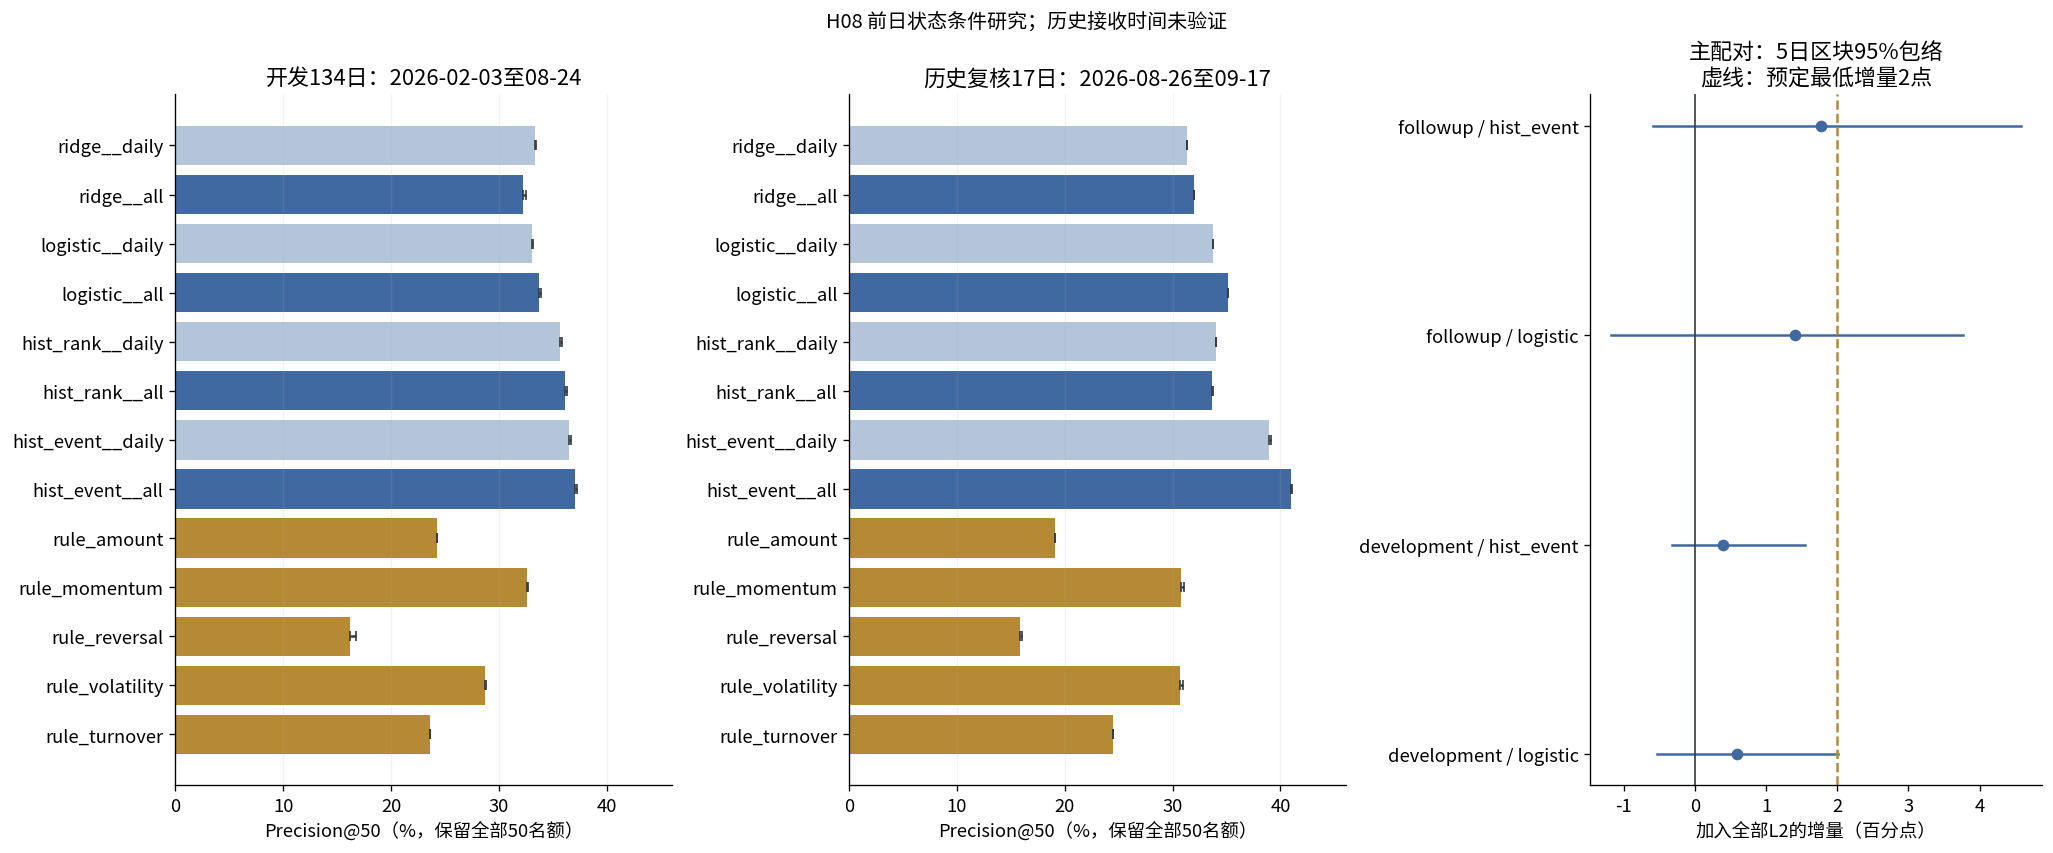

In [9]:
shown = [
    f"{family}__{group}"
    for family in parameters["families"]
    for group in ["daily", "all"]
] + list(rules)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 7),
    layout="constrained",
    gridspec_kw={"width_ratios": [1.1, 1.1, 1]},
)
for axis, stage, title in [
    (axes[0], "development", "开发134日：2026-02-03至08-24"),
    (axes[1], "followup", "历史复核17日：2026-08-26至09-17"),
]:
    rows = summary.loc[stage].loc[shown]
    colors = [
        "#4169a1"
        if name.endswith("__all")
        else "#b5c5d9"
        if "__" in name
        else "#b68a35"
        for name in shown
    ]
    axis.barh(shown, rows.precision_lower * 100, color=colors)
    axis.errorbar(
        rows.precision_lower * 100,
        np.arange(len(rows)),
        xerr=np.array(
            [np.zeros(len(rows)), (rows.precision_upper - rows.precision_lower) * 100]
        ),
        fmt="none",
        color="#343a40",
        capsize=3,
    )
    axis.invert_yaxis()
    axis.set(
        xlabel="Precision@50（%，保留全部50名额）",
        title=title,
        xlim=(0, max(summary.precision_upper) * 110),
    )
    axis.grid(axis="x", alpha=0.15)
primary = intervals.loc[
    intervals.block.eq(5)
    & intervals.contrast.isin(["l2:logistic:all", "l2:hist_event:all"])
].copy()
for position, (lower_end, upper_end, mean_value) in enumerate(
    primary[["lower_025", "upper_975", "lower_mean"]].to_numpy(dtype=float)
):
    axes[2].plot(
        [lower_end * 100, upper_end * 100], [position, position], color="#4169a1"
    )
    axes[2].plot(mean_value * 100, position, "o", color="#4169a1")
axes[2].set_yticks(
    range(len(primary)),
    (primary.stage + " / " + primary.contrast.str.split(":").str[1]).tolist(),
)
axes[2].axvline(0, color="#343a40", lw=1)
axes[2].axvline(
    parameters["minimum_increment"] * 100,
    color="#b68a35",
    ls="--",
    label="预定最低增量2点",
)
axes[2].set(
    xlabel="加入全部L2的增量（百分点）",
    title="主配对：5日区块95%包络\n虚线：预定最低增量2点",
)
fig.suptitle("H08 前日状态条件研究；历史接收时间未验证", fontsize=12)
fig.savefig(evidence / "objective-and-increment.png", bbox_inches="tight")
plt.show()

## 10. 分组消融、月度稳定性和校准

每个L2组都与相同学习器daily重新拟合配对；组间高度相关时，不能将单列重要性解释为独立贡献。
月图使用原全池top50，不在月份或组内重新选择。校准图只显示有观测的固定概率箱，空箱保持缺失。
高概率尾箱可能只有数个样本，图中对少于100个已知标签的箱标注n；不将稀疏尾箱解释为可靠校准证据。

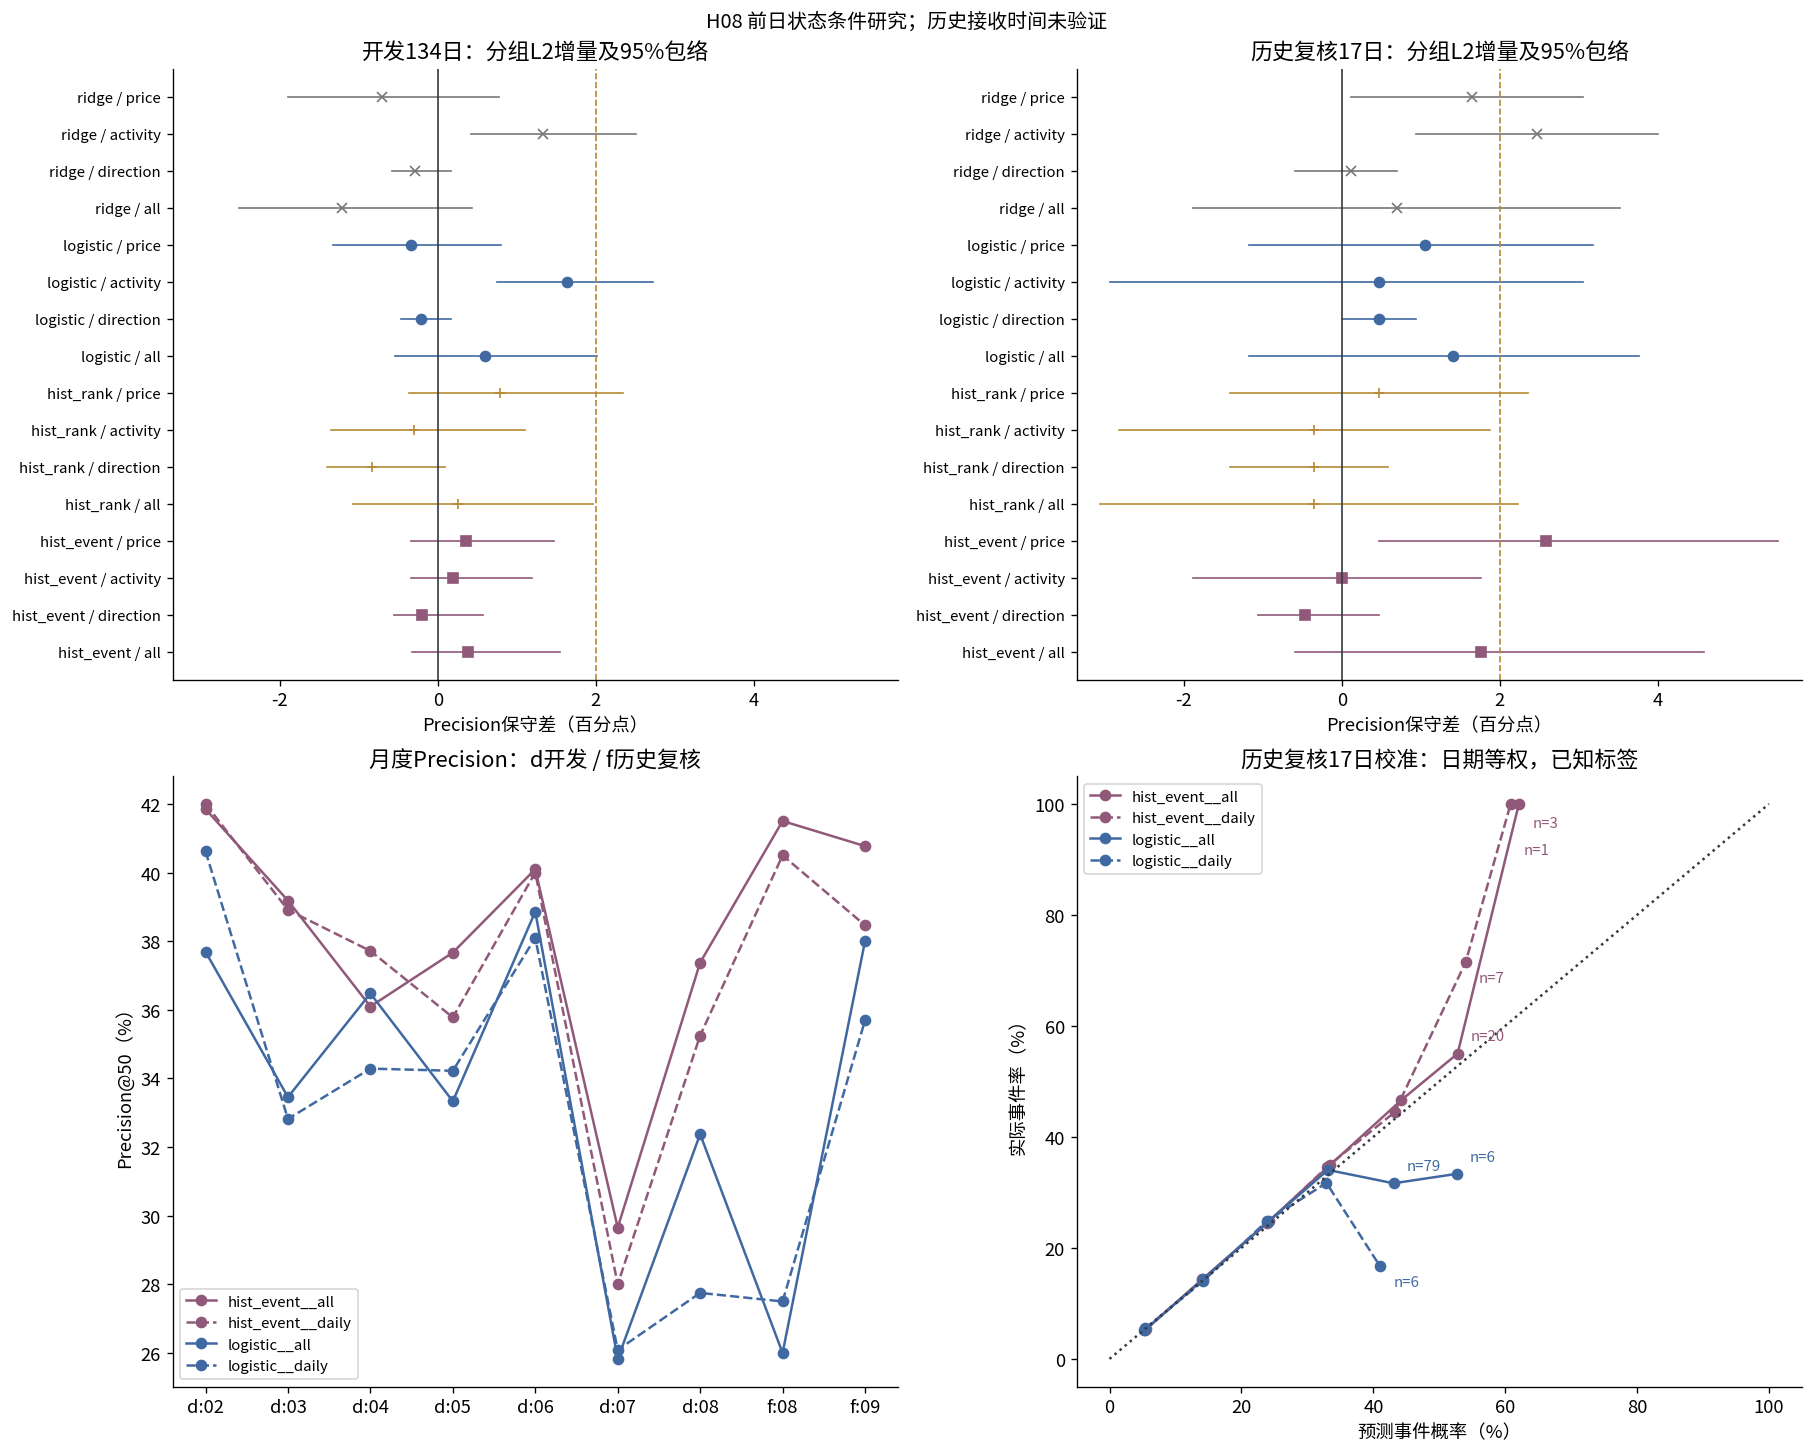

,,coverage,brier,log_loss
stage,method,,,
development,logistic__daily,0.99931,0.08515,0.29941
followup,logistic__daily,0.99952,0.08456,0.29860
development,logistic__all,0.99931,0.08445,0.29589
followup,logistic__all,0.99952,0.08376,0.29482
development,hist_event__daily,0.99931,0.08446,0.29596
followup,hist_event__daily,0.99952,0.08379,0.29469
development,hist_event__all,0.99931,0.08415,0.29455
followup,hist_event__all,0.99952,0.08336,0.29289
development,prior_probability,0.99931,0.09035,0.32605


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), layout="constrained")
l2_rows = intervals.loc[
    intervals.block.eq(5) & intervals.contrast.str.startswith("l2:")
]
shared_limits = (
    l2_rows.lower_025.min() * 100 - 0.3,
    l2_rows.upper_975.max() * 100 + 0.3,
)
for axis, stage, title in [
    (axes[0, 0], "development", "开发134日：分组L2增量及95%包络"),
    (axes[0, 1], "followup", "历史复核17日：分组L2增量及95%包络"),
]:
    rows = l2_rows.loc[l2_rows.stage.eq(stage)].set_index("contrast")
    names: list[str] = []
    positions: list[int] = []
    for family, color, marker in [
        ("ridge", "#777777", "x"),
        ("logistic", "#4169a1", "o"),
        ("hist_rank", "#b68a35", "+"),
        ("hist_event", "#915979", "s"),
    ]:
        for group in ["price", "activity", "direction", "all"]:
            group_row = rows.loc[f"l2:{family}:{group}"]
            position = len(names)
            axis.plot(
                [group_row.lower_025 * 100, group_row.upper_975 * 100],
                [position, position],
                color=color,
                lw=1,
            )
            axis.plot(group_row.lower_mean * 100, position, color=color, marker=marker)
            names.append(f"{family} / {group}")
            positions.append(position)
    axis.set_yticks(positions, names, fontsize=9)
    axis.invert_yaxis()
    axis.axvline(0, color="#343a40", lw=1)
    axis.axvline(2, color="#b68a35", ls="--", lw=1)
    axis.set(title=title, xlabel="Precision保守差（百分点）", xlim=shared_limits)
for method, color, style in [
    ("hist_event__all", "#915979", "-"),
    ("hist_event__daily", "#915979", "--"),
    ("logistic__all", "#4169a1", "-"),
    ("logistic__daily", "#4169a1", "--"),
]:
    month_rows = monthly.reset_index()
    month_rows = month_rows.loc[month_rows.method.eq(method)]
    axes[1, 0].plot(
        month_rows["stage"].str[0] + ":" + month_rows["month"].str[5:],
        month_rows.precision_lower * 100,
        color=color,
        ls=style,
        marker="o",
        label=method,
    )
    curve = calibration.xs(("followup", method), level=["stage", "method"])
    axes[1, 1].plot(
        curve.predicted * 100,
        curve.observed * 100,
        color=color,
        ls=style,
        marker="o",
        label=method,
    )
    for bin_count, predicted, observed in curve.loc[
        curve["count"].between(1, 99), ["count", "predicted", "observed"]
    ].to_numpy(dtype=float):
        axes[1, 1].annotate(
            f"n={int(bin_count)}",
            (predicted * 100, observed * 100),
            xytext=(
                8,
                (-14 if method.endswith("__all") else -30)
                if observed > 0.9
                else (-12 if method.endswith("__daily") else 8),
            ),
            textcoords="offset points",
            color=color,
            fontsize=9,
        )
axes[1, 0].set(title="月度Precision：d开发 / f历史复核", ylabel="Precision@50（%）")
axes[1, 0].legend(fontsize=9)
axes[1, 1].plot([0, 100], [0, 100], color="#343a40", ls=":")
axes[1, 1].set(
    title="历史复核17日校准：日期等权，已知标签",
    xlabel="预测事件概率（%）",
    ylabel="实际事件率（%）",
)
axes[1, 1].legend(fontsize=9)
fig.suptitle("H08 前日状态条件研究；历史接收时间未验证", fontsize=12)
fig.savefig(evidence / "groups-and-calibration.png", bbox_inches="tight")
plt.show()
display(
    probability_summary.loc[
        (
            slice(None),
            [
                "logistic__daily",
                "logistic__all",
                "hist_event__daily",
                "hist_event__all",
                "prior_probability",
            ],
        ),
        ["coverage", "brier", "log_loss"],
    ].round(5)
)

## 11. 事后状态风险与全部结果
以下T日状态仅用于量化前日过滤的局限，不能反向修改候选或预测。
与H07对比同时改变了股票池和拟合样本，不作为单一原因的因果估计。
未知标签保留上下界。严格历史可用性依旧未验证，研究结果不自动采用。

In [11]:
retrospective = pd.read_parquet(inputs / "audit/retrospective-status-audit.parquet")
post_audit = qualification.merge(
    retrospective.drop(columns="y_rank_return"),
    on=["symbol", "trade_date"],
    how="left",
    validate="one_to_one",
)
assert post_audit.listing_source_compatible.all()
retained = post_audit.loc[post_audit.eligible]
residuals = {
    "retained_but_target_day_st": int(retained.st_in_partition.sum()),
    "retained_but_target_day_S_event": int(retained.S_event_in_partition.sum()),
    "retained_but_target_day_source_uncovered": int(
        (~retained.listed_in_partition).sum()
    ),
    "retained_but_fails_target_day_mechanical_mask": int(
        (~retained.eligible_at_audit).sum()
    ),
    "target_day_fields_used_for_eligibility": False,
}
post_audit.loc[post_audit.eligible & ~post_audit.eligible_at_audit].to_parquet(
    evidence / "target-day-residuals.parquet",
    index=False,
)
_write_json(evidence / "target-day-residuals.json", residuals)
previous_summary = pd.read_csv(inputs / "h07/summary.csv").set_index(
    ["stage", "method"]
)
comparison = summary[["precision_lower", "precision_upper", "unknown"]].join(
    previous_summary[["precision_lower", "precision_upper", "unknown"]], rsuffix="_h07"
)
comparison["change_lower_points"] = (
    comparison.precision_lower - comparison.precision_lower_h07
) * 100
comparison.to_csv(evidence / "h07-comparison.csv")
display(pd.Series(residuals, name="事后诊断，未进入候选过滤").to_frame())

subgroup_summary = subgroups.groupby(["stage", "method", "dimension", "group"]).agg(
    days=("trade_date", "size"),
    pool=("pool", "sum"),
    selected=("selected", "sum"),
    hits=("hits", "sum"),
    unknown=("unknown", "sum"),
    pool_known=("pool_known", "sum"),
    pool_events=("pool_events", "sum"),
)
subgroup_summary["allocation_share"] = subgroup_summary.selected / (
    subgroup_summary.days * parameters["k"]
)
subgroup_summary["hit_contribution"] = subgroup_summary.hits / (
    subgroup_summary.days * parameters["k"]
)
subgroup_summary["selected_precision"] = (
    subgroup_summary.hits / subgroup_summary.selected.replace(0, np.nan)
)
subgroup_summary["pool_event_rate"] = (
    subgroup_summary.pool_events / subgroup_summary.pool_known.replace(0, np.nan)
)
subgroup_summary.to_csv(evidence / "subgroup-summary.csv")
judgements = []
for family in ["logistic", "hist_event"]:
    rows = primary.loc[primary.contrast.eq(f"l2:{family}:all")]
    assert len(rows) == 2
    judgements.append(
        {
            "family": family,
            "both_periods_pass": bool(
                (
                    (rows.lower_mean >= parameters["minimum_increment"])
                    & (rows.primary_bonferroni_lower > 0)
                ).all()
            ),
            "development_excludes_2pp": bool(
                rows.loc[rows.stage.eq("development"), "upper_95"].iloc[0]
                < parameters["minimum_increment"]
            ),
            "followup_excludes_2pp": bool(
                rows.loc[rows.stage.eq("followup"), "upper_95"].iloc[0]
                < parameters["minimum_increment"]
            ),
        }
    )
for input_record in input_records:
    assert _sha256(Path(input_record["source"])) == input_record["sha256"]
    assert _sha256(inputs / input_record["path"]) == input_record["sha256"]
_write_json(
    evidence / "result.json",
    {
        "judgements": judgements,
        "strongest_rule": strongest_rule,
        "fits": len(fit_records),
        "input_files": len(input_records),
        "inputs_unchanged": True,
        "independent_final": False,
        "historical_availability_verified": False,
        "scenario_only": True,
        "verification": verification,
    },
)
artifact_records = [
    {
        "path": str(path.relative_to(evidence)),
        "sha256": _sha256(path),
        "size_bytes": path.stat().st_size,
    }
    for path in sorted(evidence.rglob("*"))
    if path.is_file() and path.name != "execution-checkpoint.ipynb"
]
_write_json(evidence / "artifact-manifest.json", artifact_records)
display(pd.DataFrame(judgements))
print(f"证据目录：{evidence}")

,事后诊断，未进入候选过滤
retained_but_target_day_st,0
retained_but_target_day_S_event,341
retained_but_target_day_source_uncovered,0
retained_but_fails_target_day_mechanical_mask,341
target_day_fields_used_for_eligibility,False


,family,both_periods_pass,development_excludes_2pp,followup_excludes_2pp
0,logistic,False,True,False
1,hist_event,False,True,False


证据目录：/home/wsw/app/research-evidence/subscription-qualified-2026-09-24-fyg_q9_u


<a id="h08-strict-protocol"></a>

## H08 2026-09-23 共同资格规则与严格验收

运行前完整记录：[冻结 README](/home/wsw/app/research-evidence/subscription-universe-2026-09-23-2r2773o8/source-README.md)。以下为便于阅读迁入的说明，原冻结记录不回写。

1. 对每个决策时点，用当时可知且有效的上市成员、ST状态和停牌状态构造资格集合；
   已摘牌/不在有效上市成员中的证券、ST和仍停牌证券不进入训练候选或推理候选。
   复牌状态本身不构成排除理由；停复牌交替须由时点状态确定。
2. 日频和L2从同一集合连接各自特征，不能分别按行情覆盖、未来收益或标签是否存在删行。
   监督训练在该共同候选集合内只使用成熟的有效标签；推理不要求未来标签存在。
3. 不用T+1事后停牌、摘牌或T日买入窗口的未来成交情况反向筛T盘前集合。已经事前公布的
   状态计划，只有在能够证明其公布/接收时间及生效时间时才可使用。
4. 状态缺失、可用时间未知或晚于决策时间时，不能默认“正常上市且非ST、未停牌”。
   原始事实保留，待补齐必要证据；文件mtime和当前补录时间不证明历史可知性。
5. 本轮不改变39列原特征、原价格窗口、原全市场排名标签或K=50。筛选后原标签仍表示
   H06原排名范围的前10%，不能改称“筛选后股票池的前10%”；若以后改变排名范围须另行
   明确并重算。旧H07模型和指标不能冒充筛选后重训结果。

- Acceptance（执行前固定）: 人工样本中正常及已复牌证券保留，ST/停牌/摘牌排除；
  未来或未知可用时间被拒绝；标签改变不改变资格，日频/L2候选key一致；冻结输入key唯一、
  源/副本hash一致、过滤前后行数和未知标签守恒、所有排除都有来源；明确区分日终状态
  诊断和盘前可用性。Notebook从头执行并保存输入和结果；没有盘前证据时不执行声称真实
  时点可用的回放。2026-09-24另行授权的条件研究按[前日状态条件方案](#h08-protocol-20260924)执行，不视为严格验收通过。
- Stop: 仅验证这套用户指定的资格规则及既有窗口，不试多个过滤阈值或窗口，不根据未知
  数量改标签；历史日终状态不能证明盘前可知时，不进入声称实际可执行的历史回放。


<a id="h08-protocol-20260924"></a>

## H08 2026-09-24 前日状态条件研究的冻结方案

运行前完整记录：[冻结 README](/home/wsw/app/research-evidence/subscription-qualified-2026-09-24-fyg_q9_u/preregistered-README.md)。以下为便于阅读迁入的说明，原冻结记录不回写。

用户对上一轮解决方案明确要求“执行”。本轮保留H06的T日09:00选池，以及前一交易日P的
输入在P日22:00可用的情景假设，使用本地三表的P日分区；**不是历史接收日志回放**。
这增加了“当前保存/补取的P日状态版本在P日22:00已经存在”的未验证假设；真实历史可用性
仍为未通过，不把补取时间伪装成历史接收时间。上述严格验收及旧失败证据继续保留。

- 共同资格：先按P日 `stock_basic` 成员连接上市日期；名单缺席记为 `source_uncovered`，
  不能称为已摘牌；空/非法上市日期和晚于T日的日期分别排除，不从其他日期填补。
  P日ST排除。P日全天S且无R的状态延续为停牌；明确在P日收盘前结束的日内S允许保留，
  单独R允许保留。时间倒置、零长度区间、无时序的全天S/R冲突标为状态不明并排除。
  这只验证前日状态规则，不能保证排除T日新增ST、停牌或摘牌，也可能延迟纳入T日复牌证券。
- 时间选择理由：当前[ST接口文档](https://tushare.pro/document/2?doc_id=397)写明09:20更新，
  [停复牌接口](https://tushare.pro/document/2?doc_id=214)不定期更新；T日记录不能直接用于
  09:00候选。T日记录只用于事后诊断残留风险，不参与资格、拟合或选池。
- 输入边界：保留全部213个目标日。新增需要的P=2025-11-05股票列表也缺少 `trade_date`，
  在隔离研究目录补取 `bak_basic(20251105)`，保留旧文件和实际接收时间；不写回正式数据。
  其他P日使用已修复本地记录，冻结内容和hash。全市场空上市日期和退市整理期源缺口不再
  单独阻止共同已确认候选上的条件研究，但不改写源表或宣称完整上市覆盖通过。
- 实现边界：在现有 `universe_filter.ipynb` 中保存每次条件决策的来源日期、假设可用时间、
  实际观测时间、原表hash、逐股资格及排除原因，训练和推理从同一资格表取key。
  实际接收时间与假设时间分列；严格时间检查仍拒绝未知或决策之后收到的数据。
  正式推理接入和决策前实时采集仍需正式化，研究快照不冒充线上采集已经启用。
- 模型/数据：H07固定20配置、五规则、39列特征、原始排名标签、K=50、月度扩展训练及
  日期等权保持不变。仅成熟且已知的共同候选标签参与拟合，所有资格通过行都预测；不因
  标签或L2缺失删除推理行，不补选。原H06预测相等断言不适用于已改变的拟合样本，改为
  验证原日程不变、拟合样本精确等于资格表内成熟已知行，并逐模型重载恢复全部预测。
- 评价/停止：仍为开发134日和已消费的历史复核17日，没有独立最终验证集。沿用H07主比较、
  日期区块bootstrap、缺失上下界及最低2个百分点增量门槛。固定配置只完整运行一次；
  技术失败保留后可修复重跑，不因结果追加候选或挑选过滤规则。
- 额外验收：未上市/空日期/源未覆盖/全天停牌/复牌/已结束临停/冲突状态回归；移除全部
  标签及L2列不改变资格；过滤前后行数与未知标签守恒；所有模型同日预测key一致；
  原始特征与标签逐值不变；状态的P日期和假设可用时间不晚于决策；源及副本运行后hash
  一致。研究通过与严格历史可用性未通过分别报告，不以一个成功标志覆盖后者。


<a id="h08-source-audit-20260923"></a>

## H08 2026-09-23 修复前状态源与窗口核查

本节旧诊断的代码与输入均在所列归档；本文件当前代码执行 2026-09-24 条件重训。

以下为修复前冻结输入的核查；当前维护结果见[后续修复记录](README.md#stock-basic-repair-2026-09-23)。

执行见 [`universe_filter.ipynb`](universe_filter.ipynb)。共同资格谓词的人工回归通过：正常及
已复牌证券保留，ST/停牌/摘牌证券排除；标签和L2缺失不改变资格，未知或未来可用时间拒绝
进入历史决策。它是研究内的规则验证，尚未接入正式训练或推理入口。

**真实数据尚未通过资格回放验收**：213个目标日期中，164份非空 `stock_basic` 没有
`trade_date`，不符合历史日列表契约；其中合计出现5,193个尚未上市的股票日成员。
例如 `2025-11-06` 列表包含78只晚于该日上市的证券。其余49份有正确交易日期且未发现
未来上市成员，但仍缺少历史可用时间证据；日期结构通过不等于盘前可用性通过。
164份不合格日期覆盖848,828个H06面板股票日，不能默认它们都符合或都不符合资格。

仅对49个日期结构通过的分区，按“在当日列表、非当日ST、没有当日S事件”做事后交叉核查：

| 集合 | 股票日 | 已知标签 | 未知标签 |
| --- | ---: | ---: | ---: |
| H06原面板 | 1,103,651 | 1,102,117 | 1,534 |
| 49日部分：按当日记录机械保留 | 244,743 | 244,673 | 70 |
| 49日部分：按当日记录机械排除 | 10,080 | 9,879 | 201 |
| 164日部分：股票列表不合格，资格未判定 | 848,828 | 847,565 | 1,263 |

这里的当日S事件不等于决策时仍停牌，不能替代公告及生效时间；R事件本身不触发排除。
保留部分仍有11个买入窗口缺价、59个次日最高价缺失。这70个只属于上述49日的事后诊断，
不是全213日的合格推理池缺失数。此前忽略股票列表质量得到的“过滤后剩393个未知标签”
只是机械求交结果，不能作为过滤验收或重训依据。

实际窗口记录也表明，全天有成交不保证指定窗口有成交：`688370@2025-11-11` 的分钟记录
在14:30有55,463股成交，下一条为14:36的1,684股；`[14:31,14:36)` 内无观测成交，
冻结标签的买入VWAP为空。`002868@2025-11-06` 同样在14:29之后直到14:37才有下一条记录。
VWAP使用窗口内实际成交金额/实际成交量，一笔有效成交即可，不要求五个分钟都存在。
空窗口不能用上一笔价格、盘口中间价或0填充；是否真实零成交还是漏采须另外核对原始行情，
也不能由历史无成交断言假设订单一定买不到。做市业务提供报价和流动性，不保证每只股票的
每个五分钟窗口成交，见[上交所科创板做市说明](https://www.sse.com.cn/aboutus/mediacenter/hotandd/c/c_20220715_5705671.shtml)。

稳定证据目录为
`/home/wsw/app/research-evidence/subscription-universe-2026-09-23-2r2773o8/`，保留至用户决定
及复核完成。以 `46ecdc1dba1a390cf7cfe8560f296cb7fcd0cbbf` 加归档研究源码为代码状态，
`run.json` 保存环境和执行前工作树，`source.tar` 保存相关owner和锁文件；
`inputs/` 冻结1,922份输入、429,042,024字节，`input-manifest.json` 绑定来源和SHA-256。
`listing-source-checks.csv`、`retrospective-status-audit.parquet`、`status-summary.csv`、
`remaining-unknown.parquet` 与 `window-examples.csv` 保存逐日、逐行结果；最终Notebook、
源码导出、README、HTML及 `final-artifact-manifest.json` 绑定本轮可恢复输出。

前两次执行因访问无 `trade_date` 的股票列表失败，分别保存在同级
`subscription-universe-2026-09-23-ujezp2j7/` 和 `subscription-universe-2026-09-23-tpelsjvz/`。
第一次把异常初步归因于空事件表，该判断不成立；第二次排除空表后仍失败，进一步核实为
非空历史列表来源不兼容。失败Notebook、输入及原始错误均保留；最终版本报告不合格日期，
不把数据检查失败转换成可用资格。6个代码单元从头执行完成，Ruff及导出源码的mypy通过；
`verification.json` 明确记录历史列表检查为失败、历史回放未就绪，训练模型数为0。

精确复算使用归档Notebook，将 `prior` 指向该证据的 `inputs/h06/`、`storage` 指向
`inputs/status/`，并把 `evidence` 设为归档之外的新目录；不得用当前状态库替换冻结输入后
仍引用本轮数值。正式数据、正式Access和训练/推理入口未改；本轮没有新命中率或收益结果。


<a id="stock-basic-repair-2026-09-23"></a>

## 2026-09-23 用户授权的历史股票列表修复

用户明确要求“修复”后，按现有 [source契约](../../docs/data/source_contract.md) 重取164日
`bak_basic(trade_date=T)`，复用正式broker和normalize，在隔离目录生成校验后，替换
`/home/wsw/app/data` 中164个raw和164个processed对象，共656个文件。
2026-09-23 12:58:08 +08:00发布完成；发布文件hash与隔离副本一致，Meta及直接上游读回通过。
另49日股票列表及213日全部 `stock_st`、`suspend_d` 原字节不变。相关13项测试通过，另经5日
正式 `Access.universe` 读取验证；下载、标准化、Access实现未变。H03/H06原特征与标签不
依赖这些状态表，本次未重算或覆盖它们。

**错误源和日期分区修复已完成，完整上市资格验收仍未通过。** 213份列表均有匹配的交易日期、
唯一代码和相同的raw/processed成员；相对旧名单恢复850个成员股票日、移除5,855个。
进一步交叉检查保留以下失败及限制：

- 单独比较新表非空 `list_date` 得到的“未来成员为0”不完整。旧表5,193个已知未来上市
  成员中，4,352个移除，841个仍在新表且上市日期全为空；新表共1,526个上市日期为空的
  股票日。按owner保留源端记录与空值，不填造日期、不自行改写成员集合。
  这841个成员与H06候选key交集为0，未进入本次候选及过滤统计；源名单本身的无未来成员
  检查没有通过。
- `300391`、`300344`、`002898` 在最后交易日已不在源名单，摘牌日也不在。`300344` 的
  移出日期3月31日对应退市整理开始，实际4月22日摘牌；`002898` 6月26日开始整理、7月17日
  摘牌，见[立方退公告](https://static.cninfo.com.cn/finalpage/2026-04-22/1225137724.PDF)和
  [赛隆退公告](https://static.cninfo.com.cn/finalpage/2026-07-17/1225428193.PDF)。源名单缺席
  不等于已摘牌。初版要求最后交易日仍在源名单的断言失败，原脚本、错误日志均保留；
  本次按owner的源端返回集合完成维护，不宣称交易所完整上市覆盖检查通过。

同一H08诊断在修复后三表上的结果为：

| 集合 | 股票日 | 已知标签 | 未知标签 |
| --- | ---: | ---: | ---: |
| H06原面板 | 1,103,651 | 1,102,117 | 1,534 |
| 按当日源名单、ST及S事件机械保留 | 1,062,185 | 1,061,804 | 381 |
| 按上述当日记录机械排除 | 41,466 | 40,313 | 1,153 |

剩余381个包括337个次日最高价缺失、43个买入窗口缺价、1个T日无标签行；最后一项为此前
已知的 `300411@2026-06-11` 停牌记录缺口，本次未改写 `suspend_d`。不以T+1状态反向筛T，
不将未知标签补为负例。统计仍为当日记录诊断，历史可用时间及盘中停复牌时点尚未通过验收，
没有重训模型；旧H07命中率不能视为筛选后的结果。

维护证据目录：`/home/wsw/app/maintenance-evidence/stock-basic-repair-2026-09-23-cx25umxv/`。
`source.tar`、操作脚本、`backup/` 与 `backup-manifest.json` 保存代码、2,556份原文件及hash；
`new/` 保存重建对象，`publication-complete.json` 及逐对象记录绑定实际发布。
`validation-addendum.json` 更正单列未来日期检查，`future-members-detail.parquet` 及
`future-members-result.json` 保存841个成员及H06交集，`coverage-limit.json` 和
`validation-initial.log` 保留覆盖失败。备份与结果保留至用户复核完成，可以精确恢复原文件。
最终研究复跑目录为
`/home/wsw/app/research-evidence/subscription-universe-2026-09-23-q5afkh1y/`，冻结1,933份输入。
`universe_filter.ipynb`、`notebook-code-final.py`、`final-README.md`、HTML和
`final-artifact-manifest.json` 绑定最终可恢复版本。6个代码单元完整执行，Ruff、mypy通过；
`verification.json` 明确保留完整上市覆盖及源名单无未来成员两项失败，以及841个成员未进入
H06的检查通过。修复后的早期展示执行保存在同级 `subscription-universe-2026-09-23-l7w6rxl2/`
与 `subscription-universe-2026-09-23-aecs799a/`，不能将前者非空日期检查的0解释为实际未来
成员为0。精确复算用最终归档，把 `prior`、`storage`、`maintenance` 分别指向
`inputs/h06/`、`inputs/status/`、`inputs/maintenance/`，`evidence` 使用归档外新目录。
设计仍为open研究草案，数据维护已落地；正式模型入口未变，未执行commit、merge、release或deploy。


<a id="h08-evidence-20260924"></a>

## H08 2026-09-24 共同资格面板、重训结果与归档

[`universe_filter.ipynb`](universe_filter.ipynb) 已从头执行前日状态条件研究：保留全部213个
目标日期，日频及L2共用资格、拟合样本和推理候选；20个固定配置完成160次月度拟合，
151个评价日保留6,700/850个入选名额。上市日期缺失不进入模型，不从未来记录补填；
未知标签不参与监督拟合、不填成负例，也不从推理候选中删除。

| 互斥资格结果 | 股票日 | 已知标签 | 未知标签 |
| --- | ---: | ---: | ---: |
| H06原面板 | 1,103,651 | 1,102,117 | 1,534 |
| 资格通过 | 1,062,525 | 1,061,806 | 719 |
| 前日ST | 40,884 | 40,113 | 771 |
| 前日源名单未覆盖 | 240 | 197 | 43 |
| 前日上市日期为空 | 1 | 1 | 0 |
| 前日停牌区间不明 | 1 | 0 | 1 |

总计排除41,126行、815个未知标签。上市日期为空的是 `301687@2026-01-05`，其
`2025-12-31` 前日名单没有上市日期；它与先前“按T日名单检查为空的H06候选为0”使用的
输入日期不同。停牌区间不明的是 `603056@2026-01-12`，前日记录为 `13:00-9:30`，
不能推断结束日期。原候选已要求P日有分钟成交，本轮没有额外命中P日全天停牌的候选。
先前841个已知预上市成员未进入原H06候选的证据继续成立，源表空值仍保留原样。

剩余719个未知标签由338个T日无标签行、337个次日最高价缺失、43个买入窗口价格缺失和
1个两端价格缺失构成。它不是先前381的复算差错：381使用了T日事后状态，719使用P日
状态情景。事后核查本轮保留集合中，T日ST及T日源名单缺席均为0，仍有341个股票日带T日
S事件；这些不一定在09:00仍停牌，不能全部事后删除。前日状态不能保证排除当天新增风险，
真实运行仍需要决策/下单时收到的最新状态，不能把本轮标成完整可交易性验收通过。

下表为日期等权Precision@50下界，分母始终包括未知标签；标签仍为H06原全市场排名。

| 学习器 | 日频：开发134日 | 全部L2：开发134日 | 日频：历史复核17日 | 全部L2：历史复核17日 |
| --- | ---: | ---: | ---: | ---: |
| Ridge排名回归 | 33.3731% | 32.2687% | 31.2941% | 32.0000% |
| Logistic事件概率 | 33.0597% | 33.7313% | 33.7647% | 35.1765% |
| 浅树排名回归 | 35.6716% | 36.0896% | 34.0000% | 33.6471% |
| 浅树事件概率 | 36.4627% | 37.0448% | 38.9412% | 40.9412% |

| 全部L2减同学习器日频 | 开发增量界（点） | 开发95%包络（点） | 复核增量界（点） | 复核95%包络（点） |
| --- | ---: | ---: | ---: | ---: |
| Logistic | [+0.5970,+0.8507] | [−0.5373,+2.0149] | +1.4118 | [−1.1794,+3.7647] |
| 浅树事件概率 | [+0.3881,+0.8060] | [−0.3284,+1.5522] | [+1.7647,+2.1176] | [−0.5882,+4.5882] |

两分类器仍未达到“两段保守均值至少2点且主比较校正下界大于0”。浅树分类复核中，L2多命中
17次（348对331），表面差为2点，但日频/L2各有2/1个未知标签，配对区间仍跨零，不能称为
显著稳定增强。开发段加入L2从旧H07的小幅下降变成小幅上升，说明具体符号对样本口径和
重新拟合敏感；Ridge仍为开发下降、复核上升。这次过滤没有识别出旧跨期差异的单一原因。
新旧比较同时改变拟合池和推理池，不能把变化全归因于未知标签或某个排除类别。

开发段冻结的最强规则仍为动量（32.5672%/30.8235%）；全部五规则、20配置及预定分组
均已披露。两分类器全部L2增量在开发段的单侧95%上限分别为1.8358/1.4478点，在当前
固定候选与情景下低于2点；历史复核仍不能排除该量级。所有历史区间均非独立确认。

稳定证据：`/home/wsw/app/research-evidence/subscription-qualified-2026-09-24-fyg_q9_u/`，
保留至用户决定及复核完成。代码状态为 `46ecdc1dba1a390cf7cfe8560f296cb7fcd0cbbf` 加
归档研究源码；`source.tar`、执行前README和 `run.json` 固定代码、方案、环境及工作树。
`inputs/` 冻结2,577份输入，`input-manifest.json` 和 `snapshot-receipts.json` 记录内容hash、
真实观测时间及未知的历史接收时间。`eligibility.parquet` 记录每股决策及排除原因；
`eligible-panel.parquet`、每月 `*-training-keys.parquet`、模型、逐日预测和全部指标可恢复。
`target-day-residuals.*` 只保存事后诊断，T日状态没有用于资格、拟合或预测。

11个代码单元完整执行；11个资格反例、213日实际晚到时间拒绝、输入/副本hash与行数守恒
检查通过。160个模型重载恢复3,020组模型日预测，独立核对3,775组名单与事件指标、1,661组
概率损失及12组bootstrap；相关13项既有测试、Ruff、格式和导出源码mypy通过。
`verification.json` 明确保留严格历史可用性与交易所完整上市覆盖为false。
最终Notebook和HTML阅读版已检查中文、图表、区间及小样本标注；展示重渲染只调整标题和
标注位置，非绘图代码与完整执行版本一致，未重新拟合。最终 `universe_filter.ipynb`、
`notebook-code-final.py`、`final-README.md`、HTML及 `final-artifact-manifest.json` 固定交付版本；
`presentation-before/` 保留初次图形，`presentation-rerender.ipynb` 保存冻结数值上的重渲染。
首次执行的旧归档路径错误保留在同级 `subscription-qualified-2026-09-24-_jupxl0b/`；
第二次连接改变证券key的字符串dtype，精确比较失败，保留在 `...-4a508xrw/`。修正为
验证连接key顺序后直接从原面板取行，保留原dtype与原比较断言；两次失败都未开始训练。

首日补取与原副本保存在
`/home/wsw/app/research-evidence/subscription-status-supplement-2026-09-24-h96prkye/`，
请求为 `bak_basic(20251105)`；实际接收时间不代表历史可用时间，没有写回正式数据。
补取前缺少 `ZERO_STORAGE_ROOT` 的配置失败记录也已保留。当前H08仍为open研究草案；
工作树更新了README及Notebook，正式训练、推理、实时采集和下单入口未切换，未执行
commit、merge、release或deploy。


<a id="h08-reproduce-20260924"></a>

## H08 2026-09-24 条件重训的精确恢复

H08使用当前 `universe_filter.ipynb`，在仓库根、项目锁定Python 3.13内核中从头执行，
会新建隔离目录。精确复算使用[2026-09-24 结果所列归档](#h08-evidence-20260924)的最终Notebook及 `source.tar`，将 `prior` 指向
`inputs/`、`storage` 指向 `inputs/status/`，`previous_audit`、`previous_event` 分别指向
`inputs/audit/`、`inputs/h07/`。将归档 `inputs/supplement/` 复制到新的恢复目录，设置为
`supplement`；再从冻结 `inputs/status/` 复制2025-11-05的 `stock_basic` raw/processed
payload及Meta四个文件，按原相对路径放入该恢复目录的 `new/`，不得改写原归档。
结果写入新的 `evidence` 目录；无需再次联网补取，也不需要生产凭证。当前正式输入发生变化后
直接重跑属于新输入的验证，不能继续引用本轮数值。


<a id="h08-two-stage-protocol"></a>

## H08 两阶段筛选：盘前停牌与 14:30 累计成交量

2026-09-24 用户明确要求两步同时使用。本节是 H08 的补充验证，独立于上方已经冻结的前日状态重训；
本节可单独从头执行，旧模型、旧执行输出和旧归档保持原版本。

- 第一阶段：T 09:00 使用截至该时点已收到的当日停复牌快照。S 排除，只出现 R 不排除；
  同日 S/R 缺少先后信息时记录为状态不明并排除。有效空快照可用；没有快照或历史可用时间不能冒充无停牌。
- 第二阶段：在第一阶段保留集合中，T 14:30 要求当天累计成交量 > 0。历史分钟采用
  `minute_start_ts_utc + 60_000_000 <= T14:30`，包含开盘集合竞价和连续竞价；
  14:30 开始的分钟尚未完成，不计入。推理需要当时已收到的累计成交快照。
- 缺少分钟观察保持未知并暂不进入第二阶段，不补零、不直接归因为停牌；真实累计量为 0 单独记录。
  截至 14:30 有成交只证明通过此门槛，不保证 14:31 买入窗口成交或次日能够退出。
- 训练回放与推理共用筛选函数及截止时点。14:30 过滤只缩减盘前候选/已订阅集合，不反向修改
  09:00 名单或事后回补 K=50。未知未来标签不影响两个阶段的资格。
- 输入固定为 H08 的 1,062,525 个候选股票日、213 个 T 日，冻结的 `suspend_d(T)`、
  本地两市股票分钟事实和 `daily_bar(T)`。日线仅作盘后对照，不进入 14:30 判定。
  不引入成交量阈值搜索、训练配置搜索或新的模型性能比较。
- 验收：仅 R 不被误删；S/R 不明被识别；0 与无观测分开；开盘成交计入；14:29 分钟计入，
  14:30 分钟与更晚成交不改变结果；晚到/未知状态和量快照被拒绝；标签变化不改变资格；
  两阶段按序且第二阶段不能新增股票；逐日期与总体计数守恒。
- 本地历史表没有盘前状态接收记录和分钟实时接收记录。严格历史输入检查必须失败；全日最终 S 表
  与事件时间截止分钟只能生成**事后诊断**，不得称为 09:00 实际可选池或实盘收益验证。
  不以假定接收时间填补本节缺口，不据此重训或替换原模型。

官方来源：[停复牌接口](https://tushare.pro/document/2?doc_id=214)区分 S/R 且不承诺固定盘前更新时间；
[日线接口](https://tushare.pro/document/2?doc_id=27)在收盘后入库。
冻结输入及采集源码位于 `/home/wsw/app/research-evidence/subscription-two-stage-2026-09-24-rucwutw9`，源文件和投影均记录 SHA-256。
先前关于完整日线成交量的只读检查不作为本节 14:30 结果或事前验证数据。


### 两阶段共用筛选函数

下面各单元独立于前面的模型训练，可只执行本节。状态和成交量快照的可用时间由调用方提供；未知或晚于对应决策时点时失败。

In [1]:
import hashlib
import json
import tempfile
from datetime import date
from datetime import time as cutoff_time
from pathlib import Path
from collections.abc import Sequence

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import display

from src.data_system.market_phase import MarketPhase
from src.utils import table_ops
from src.utils.datetime_utils import DateTimeUtils
from src.utils.parquet_writer import write_parquet_atomic

two_stage_root = Path("/home/wsw/app/research-evidence/subscription-two-stage-2026-09-24-rucwutw9")
two_stage_inputs = two_stage_root / "inputs"
two_stage_output = Path(tempfile.mkdtemp(
    prefix="subscription-two-stage-validation-2026-09-24-",
    dir=two_stage_root.parent,
))
print(f"TWO_STAGE_OUTPUT={two_stage_output}", flush=True)


def _cumulative_volume_before(
    minutes: pa.Table, *, cutoff_ts: int
) -> pd.DataFrame:
    visible = minutes.filter(
        pc.and_(
            pc.less_equal(
                pc.add(minutes["minute_start_ts_utc"], 60_000_000), cutoff_ts
            ),
            pc.is_in(
                minutes["phase"],
                value_set=pa.array(
                    [int(MarketPhase.AUCTION), int(MarketPhase.CONTINUOUS)],
                    type=pa.int8(),
                ),
            ),
        )
    )
    table_ops.require_positive(visible, ("volume_sum",), who="two-stage minutes")
    if visible.num_rows:
        maximum = int(pc.max(visible["volume_sum"]).as_py())
        if maximum * visible.num_rows > np.iinfo(np.int64).max:
            raise OverflowError("two-stage volume: integer sum bound exceeded")
    totals = visible.group_by("symbol").aggregate([("volume_sum", "sum")])
    return totals.to_pandas().rename(
        columns={"volume_sum_sum": "volume_1430"}
    ).astype({"volume_1430": "Int64"})


def _two_stage_eligibility(
    symbols: Sequence[str],
    *,
    suspend_events: pd.DataFrame,
    cumulative_volume: pd.DataFrame,
    status_available_ts: int | None,
    volume_available_ts: int | None,
    preopen_ts: int,
    cutoff_ts: int,
) -> pd.DataFrame:
    if status_available_ts is None or status_available_ts > preopen_ts:
        raise ValueError("preopen suspend snapshot availability is unverified or late")
    if volume_available_ts is None or volume_available_ts > cutoff_ts:
        raise ValueError("14:30 volume snapshot availability is unverified or late")
    table_ops.require_unique(
        cumulative_volume, ("symbol",), who="14:30 cumulative snapshot"
    )
    owned = pd.DataFrame({"symbol": list(symbols)})
    table_ops.require_unique(owned, ("symbol",), who="two-stage candidates")
    stopped = suspend_events.loc[suspend_events.suspend_type.eq("S"), "symbol"]
    resumed = suspend_events.loc[suspend_events.suspend_type.eq("R"), "symbol"]
    owned["known_s"] = owned.symbol.isin(stopped)
    owned["same_day_sr_unordered"] = owned.known_s & owned.symbol.isin(resumed)
    owned["preopen_pass"] = ~owned.known_s
    owned = owned.merge(cumulative_volume, on="symbol", how="left", validate="one_to_one")
    owned["volume_observed"] = owned.volume_1430.notna()
    owned["volume_positive"] = owned.volume_1430.gt(0).fillna(False).astype(bool)
    owned["eligible_1430"] = owned.preopen_pass & owned.volume_positive
    owned["reason"] = np.select(
        [
            owned.same_day_sr_unordered,
            owned.known_s,
            ~owned.volume_observed,
            ~owned.volume_positive,
        ],
        [
            "suspension_order_unknown",
            "preopen_known_suspension",
            "volume_unobserved_at_1430",
            "nonpositive_volume_at_1430",
        ],
        default="eligible",
    )
    return owned


TWO_STAGE_OUTPUT=/home/wsw/app/research-evidence/subscription-two-stage-validation-2026-09-24-fa1wz9rk


### 时间边界与资格反例

人工快照只用于验证代码行为，不代表历史接收事实。

In [2]:
two_stage_fixture_day = date(2026, 8, 21)
two_stage_preopen = DateTimeUtils.local_time_to_utc_epoch_us(
    cutoff_time(9), two_stage_fixture_day
)
two_stage_cutoff = DateTimeUtils.local_time_to_utc_epoch_us(
    cutoff_time(14, 30), two_stage_fixture_day
)
two_stage_open = DateTimeUtils.local_time_to_utc_epoch_us(
    cutoff_time(9, 25), two_stage_fixture_day
)
two_stage_fixture_minutes = pa.table({
    "symbol": ["open", "open", "last", "future"],
    "minute_start_ts_utc": [
        two_stage_open, two_stage_cutoff, two_stage_cutoff - 60_000_000,
        two_stage_cutoff,
    ],
    "phase": pa.array([0, 2, 2, 2], type=pa.int8()),
    "volume_sum": pa.array([5, 1000, 7, 500], type=pa.int64()),
})
two_stage_fixture_volume = _cumulative_volume_before(
    two_stage_fixture_minutes, cutoff_ts=two_stage_cutoff
)
assert two_stage_fixture_volume.set_index("symbol").volume_1430.to_dict() == {
    "open": 5, "last": 7
}
two_stage_fixture_events = pd.DataFrame({
    "symbol": ["stop", "resume", "both", "both"],
    "suspend_type": ["S", "R", "S", "R"],
})
two_stage_fixture_extra_volume = pd.DataFrame({
    "symbol": ["stop", "resume", "both", "zero"],
    "volume_1430": pd.Series([100, 100, 100, 0], dtype="Int64"),
})
two_stage_fixture_volume = pd.concat(
    [two_stage_fixture_volume, two_stage_fixture_extra_volume], ignore_index=True
)
two_stage_fixture_symbols = ["open", "last", "future", "stop", "resume", "both", "zero", "absent"]
two_stage_fixture_kwargs = {
    "suspend_events": two_stage_fixture_events,
    "cumulative_volume": two_stage_fixture_volume,
    "status_available_ts": two_stage_preopen - 1,
    "volume_available_ts": two_stage_cutoff,
    "preopen_ts": two_stage_preopen,
    "cutoff_ts": two_stage_cutoff,
}
two_stage_fixture_result = _two_stage_eligibility(
    two_stage_fixture_symbols, **two_stage_fixture_kwargs
).set_index("symbol")
assert set(two_stage_fixture_result.index[two_stage_fixture_result.eligible_1430]) == {
    "open", "last", "resume"
}
assert two_stage_fixture_result.loc["both", "reason"] == "suspension_order_unknown"
assert two_stage_fixture_result.loc["zero", "reason"] == "nonpositive_volume_at_1430"
assert two_stage_fixture_result.loc["absent", "reason"] == "volume_unobserved_at_1430"
assert pd.isna(two_stage_fixture_result.loc["future", "volume_1430"])
assert not two_stage_fixture_result.loc["stop", "eligible_1430"]
two_stage_rejected_receipts = 0
for name, unavailable in [
    ("status_available_ts", None),
    ("status_available_ts", two_stage_preopen + 1),
    ("volume_available_ts", None),
    ("volume_available_ts", two_stage_cutoff + 1),
]:
    changed = {**two_stage_fixture_kwargs, name: unavailable}
    try:
        _two_stage_eligibility(two_stage_fixture_symbols, **changed)
    except ValueError:
        two_stage_rejected_receipts += 1
    else:
        raise AssertionError((name, unavailable))
assert two_stage_rejected_receipts == 4
two_stage_future_minutes = pa.concat_tables([
    two_stage_fixture_minutes,
    pa.table({
        "symbol": ["future", "open"],
        "minute_start_ts_utc": [two_stage_cutoff + 60_000_000] * 2,
        "phase": pa.array([2, 2], type=pa.int8()),
        "volume_sum": pa.array([999999, 999999], type=pa.int64()),
    }),
])
pd.testing.assert_frame_equal(
    _cumulative_volume_before(two_stage_fixture_minutes, cutoff_ts=two_stage_cutoff),
    _cumulative_volume_before(two_stage_future_minutes, cutoff_ts=two_stage_cutoff),
)
two_stage_label_fixture = pd.DataFrame({
    "symbol": two_stage_fixture_symbols,
    "future_label": [None, 0, 1, None, 1, 0, 1, None],
})
two_stage_without_labels = _two_stage_eligibility(
    two_stage_label_fixture.symbol.tolist(), **two_stage_fixture_kwargs
)
two_stage_label_fixture["future_label"] = 99
pd.testing.assert_frame_equal(
    two_stage_without_labels,
    _two_stage_eligibility(two_stage_label_fixture.symbol.tolist(), **two_stage_fixture_kwargs),
)
assert (two_stage_fixture_result.eligible_1430 <= two_stage_fixture_result.preopen_pass).all()
display(two_stage_fixture_result)
print("边界反例通过：S/R、零与未知、开盘及14:29成交、14:30及以后不污染、四种不可用时间、标签独立、集合只缩减。")


,known_s,same_day_sr_unordered,preopen_pass,volume_1430,volume_observed,volume_positive,eligible_1430,reason
symbol,,,,,,,,
open,False,False,True,5,True,True,True,eligible
last,False,False,True,7,True,True,True,eligible
future,False,False,True,<NA>,False,False,False,volume_unobserved_at_1430
stop,True,False,False,100,True,True,False,preopen_known_suspension
resume,False,False,True,100,True,True,True,eligible
both,True,True,False,100,True,True,False,suspension_order_unknown
zero,False,False,True,0,True,False,False,nonpositive_volume_at_1430
absent,False,False,True,<NA>,False,False,False,volume_unobserved_at_1430


边界反例通过：S/R、零与未知、开盘及14:29成交、14:30及以后不污染、四种不可用时间、标签独立、集合只缩减。


### 冻结输入与全量事后核查

每份输入先校验采集清单 SHA-256。分钟源的 Meta、上游存在性、schema、日期和唯一键已在采集时由正式 Access 校验。本节严格入口拒绝未知历史接收时间，再单独统计最终日表与事件时间分钟的交叉事实。

In [3]:
two_stage_manifest = json.loads((two_stage_root / "input-manifest.json").read_text())
for record in two_stage_manifest:
    with (two_stage_root / record["path"]).open("rb") as stream:
        digest = hashlib.file_digest(stream, "sha256").hexdigest()
    assert digest == record["sha256"], record["path"]
two_stage_candidates = pd.read_parquet(two_stage_inputs / "candidate-keys.parquet")
two_stage_unknowns = pd.read_parquet(two_stage_inputs / "remaining-unknown.parquet")
table_ops.require_unique(
    two_stage_candidates, ("symbol", "trade_date"), who="frozen H08 candidates"
)
assert len(two_stage_candidates) == 1062525
assert two_stage_candidates.trade_date.nunique() == 213
assert two_stage_candidates.y_rank_return.isna().sum() == 719
two_stage_parts = []
two_stage_strict_rejections = []
for day, candidates in two_stage_candidates.groupby("trade_date", sort=True):
    market_day = date.fromisoformat(str(day))
    preopen_ts = DateTimeUtils.local_time_to_utc_epoch_us(cutoff_time(9), market_day)
    cutoff_ts = DateTimeUtils.local_time_to_utc_epoch_us(cutoff_time(14, 30), market_day)
    events = pd.read_parquet(two_stage_inputs / "status" / f"{day}.parquet")
    bars = pd.read_parquet(two_stage_inputs / "daily" / f"{day}.parquet")
    minutes = pq.read_table(two_stage_inputs / "minutes" / f"{day}.parquet")
    assert events.suspend_type.isin(["S", "R"]).all()
    assert events.trade_date.eq(day).all() and bars.trade_date.eq(day).all()
    assert pc.all(pc.equal(minutes["trade_date"], str(day))).as_py()
    cumulative = _cumulative_volume_before(minutes, cutoff_ts=cutoff_ts)
    try:
        _two_stage_eligibility(
            candidates.symbol.tolist(),
            suspend_events=events,
            cumulative_volume=cumulative,
            status_available_ts=None,
            volume_available_ts=None,
            preopen_ts=preopen_ts,
            cutoff_ts=cutoff_ts,
        )
    except ValueError as error:
        two_stage_strict_rejections.append({"trade_date": day, "reason": str(error)})
    else:
        raise AssertionError("historical missing receipt incorrectly accepted")

    # Final daily status is diagnostic evidence, not a historical 09:00 snapshot.
    cumulative["symbol"] = cumulative.symbol.astype(candidates.symbol.dtype)
    audit = candidates.merge(cumulative, on="symbol", how="left", validate="one_to_one")
    audit["final_day_s"] = audit.symbol.isin(
        events.loc[events.suspend_type.eq("S"), "symbol"]
    )
    audit["final_day_r"] = audit.symbol.isin(
        events.loc[events.suspend_type.eq("R"), "symbol"]
    )
    audit["volume_before_1430_observed"] = audit.volume_1430.notna()
    audit["volume_before_1430_positive"] = audit.volume_1430.gt(0).fillna(False).astype(bool)
    audit["diagnostic_after_final_s"] = ~audit.final_day_s
    audit["diagnostic_after_both"] = (
        audit.diagnostic_after_final_s & audit.volume_before_1430_positive
    )
    bars = bars.rename(columns={"vol": "full_day_volume"}).drop(columns="trade_date")
    bars["symbol"] = bars.symbol.astype(candidates.symbol.dtype)
    bars["daily_row_present"] = True
    audit = audit.merge(bars, on="symbol", how="left", validate="one_to_one")
    audit["daily_row_present"] = audit.daily_row_present.eq(True)
    audit["full_day_positive"] = audit.full_day_volume.gt(0).fillna(False).astype(bool)
    audit["unknown_label"] = audit.y_rank_return.isna()
    audit["strict_preopen_verified"] = False
    audit["strict_volume_receipt_verified"] = False
    assert len(audit) == len(candidates)
    assert (audit.diagnostic_after_both <= audit.diagnostic_after_final_s).all()
    two_stage_parts.append(audit)
two_stage_audit = pd.concat(two_stage_parts, ignore_index=True)
assert len(two_stage_audit) == len(two_stage_candidates)
assert len(two_stage_strict_rejections) == 213
two_stage_reference = two_stage_candidates.sort_values(["trade_date", "symbol"]).reset_index(drop=True)
pd.testing.assert_frame_equal(
    two_stage_audit[two_stage_candidates.columns].sort_values(
        ["trade_date", "symbol"]
    ).reset_index(drop=True),
    two_stage_reference,
)
write_parquet_atomic(
    output_file=two_stage_output / "two-stage-audit.parquet",
    table=pa.Table.from_pandas(two_stage_audit, preserve_index=False),
)
pd.DataFrame(two_stage_strict_rejections).to_csv(
    two_stage_output / "strict-rejections.csv", index=False
)


### 两阶段核查结果

以下结果不代表当时09:00已经知道T日最终停牌表，也不证明历史分钟实时到达。完整日线只展示与14:30前观察的差异。

分钟累计量沿用源数值尺度，Tushare日线vol为手；本节只比较是否大于0，不直接比较两列数值大小。

In [4]:
two_stage_rows = []
for label, mask in [
    ("H08共同候选", pd.Series(True, index=two_stage_audit.index)),
    ("仅核查14:30前正成交", two_stage_audit.volume_before_1430_positive),
    ("事后排除T日最终S记录", two_stage_audit.diagnostic_after_final_s),
    ("事后S排除后再要求14:30前正成交", two_stage_audit.diagnostic_after_both),
]:
    subset = two_stage_audit.loc[mask]
    two_stage_rows.append({
        "核查口径": label, "股票日": len(subset),
        "已知标签": int((~subset.unknown_label).sum()),
        "未知标签": int(subset.unknown_label.sum()),
    })
two_stage_summary = pd.DataFrame(two_stage_rows)
two_stage_summary.to_csv(two_stage_output / "summary.csv", index=False)
two_stage_cross = two_stage_audit.groupby(
    ["final_day_s", "volume_before_1430_observed", "full_day_positive"],
    dropna=False,
).agg(股票日=("symbol", "size"), 未知标签=("unknown_label", "sum")).reset_index()
two_stage_cross.to_csv(two_stage_output / "cross-check.csv", index=False)
two_stage_retained_unknown = two_stage_unknowns.merge(
    two_stage_audit.loc[
        two_stage_audit.diagnostic_after_both, ["symbol", "trade_date"]
    ],
    on=["symbol", "trade_date"], how="inner", validate="one_to_one",
)
two_stage_remaining_causes = two_stage_retained_unknown.groupby("cause").size().rename("股票日")
two_stage_remaining_causes.to_csv(two_stage_output / "remaining-unknown-causes.csv")
two_stage_disagreements = two_stage_audit.loc[
    two_stage_audit.full_day_positive.ne(two_stage_audit.volume_before_1430_positive)
    | (two_stage_audit.final_day_s & two_stage_audit.volume_before_1430_positive)
    | (~two_stage_audit.final_day_s & ~two_stage_audit.volume_before_1430_positive)
]
two_stage_disagreements.to_csv(two_stage_output / "disagreements.csv", index=False)
two_stage_checks = {
    "candidate_rows_unchanged": len(two_stage_audit),
    "dates_checked": int(two_stage_audit.trade_date.nunique()),
    "strict_historical_dates_rejected": len(two_stage_strict_rejections),
    "status_receipt_verified": False,
    "minute_receipt_verified": False,
    "future_labels_used_for_filter": False,
    "full_day_volume_used_for_1430_filter": False,
    "models_retrained": 0,
    "original_predictions_changed": False,
    "final_s_with_positive_volume_before_1430": int((
        two_stage_audit.final_day_s & two_stage_audit.volume_before_1430_positive
    ).sum()),
    "no_final_s_without_observed_volume_before_1430": int((
        ~two_stage_audit.final_day_s & ~two_stage_audit.volume_before_1430_positive
    ).sum()),
    "full_day_volume_disagrees_with_prefix": int(
        two_stage_audit.full_day_positive.ne(
            two_stage_audit.volume_before_1430_positive
        ).sum()
    ),
    "boundary_examples_passed": True,
    "snapshot_availability_rejections": two_stage_rejected_receipts,
}
(two_stage_output / "verification.json").write_text(
    json.dumps(two_stage_checks, ensure_ascii=False, indent=2)
)
display(two_stage_summary)
display(two_stage_cross)
display(two_stage_remaining_causes.to_frame())
display(two_stage_disagreements[
    ["symbol", "trade_date", "final_day_s", "volume_1430",
     "full_day_volume", "unknown_label"]
].head(12))
print("以上T日最终S表仅用于事后诊断；213个日期均未通过严格历史接收验证。")
print(f"INPUTS={two_stage_root}")
print(f"OUTPUTS={two_stage_output}")


,核查口径,股票日,已知标签,未知标签
0,H08共同候选,1062525,1061806,719
1,仅核查14:30前正成交,1062187,1061806,381
2,事后排除T日最终S记录,1062184,1061803,381
3,事后S排除后再要求14:30前正成交,1062183,1061803,380


,final_day_s,volume_before_1430_observed,full_day_positive,股票日,未知标签
0,False,False,False,1,1
1,False,True,True,1062183,380
2,True,False,False,337,337
3,True,True,True,4,1


,股票日
cause,
entry_window_missing,43
next_high_missing,337


,symbol,trade_date,final_day_s,volume_1430,full_day_volume,unknown_label
47580,301638,2025-11-19,True,160911448,1754118.75,False
182024,301449,2025-12-26,True,9029242,102637.49,False
223076,603056,2026-01-09,True,4536400,45364.00,True
228338,603402,2026-01-12,True,10880606,127200.21,False
714886,300411,2026-06-11,False,<NA>,NaN,True


以上T日最终S表仅用于事后诊断；213个日期均未通过严格历史接收验证。
INPUTS=/home/wsw/app/research-evidence/subscription-two-stage-2026-09-24-rucwutw9
OUTPUTS=/home/wsw/app/research-evidence/subscription-two-stage-validation-2026-09-24-fa1wz9rk


### 本次执行事实与恢复

- 213个日期全部核查；第一阶段函数仅用已知停复牌记录，第二阶段仅用14:30前已完成分钟的累计量。
  人工快照反例验证S/R、集合只缩减、0与未知分开、未来分钟/标签不改变结果、晚到与未知时间拒绝。
- 原H08候选1,062,525行、719个未知标签。仅要求14:30前有正成交，保留1,062,187行、
  381个未知标签，全部1,061,806个已知标签样本仍在。
- 使用T日最终S表作事后诊断，先排除341行，再排除1个无14:30前成交观察的股票日，保留
  1,062,183行、380个未知标签。后者由43个买入窗口缺失与337个次日最高价缺失构成。
- 最终S记录中有4个股票日仍观察到14:30前成交，其中3个有有效标签；最终S表不能冒充盘前已知表。
  300411@2026-06-11没有S记录、日线行或14:30前分钟观察，只能记为观察缺失，不能直接认定停牌。
- 本批完整日线与14:30前累计量的“是否大于0”结果恰好一致；人工反例已验证，14:30后首次成交时二者
  会不同，因此代码仍禁止使用完整日线替代分钟前缀。
- 历史状态及分钟接收时间均缺证据；严格入口拒绝全部213日。未生成新的训练样本版本或模型，
  未重排原09:00订阅名单，也没有把上述事后结果写入正式数据或入口。

输入归档：/home/wsw/app/research-evidence/subscription-two-stage-2026-09-24-rucwutw9，input-manifest.json绑定2,134份冻结文件，
包括每日期两市分钟的必要列投影、停复牌表、日线对照及源Meta。capture_inputs.py保存采集方法，
source.tar保存项目源码与采集时的研究方案，capture-run.json记录环境和Git状态。
首次Notebook启动缺少系统python3内核，错误保存在kernel-launch-failure.log；随后使用隔离内核指向
项目锁定Python，四个新增代码单元完整执行成功。

本次执行输出：/home/wsw/app/research-evidence/subscription-two-stage-validation-2026-09-24-fa1wz9rk。
executed-two-stage.ipynb可独立阅读，two-stage-audit.parquet保留逐股票日结果，
strict-rejections.csv保留严格时间检查失败，verification.json保存验证状态。
当前完整Notebook的原11个训练/评价代码单元、执行计数和输出均与本次修改前一致。

精确复算：恢复输入归档及其source.tar的项目环境，执行输出目录中的
executed-two-stage.ipynb。如移动归档，只修改首个代码单元的two_stage_root，
输出仍进入新建隔离目录；不必调用Tushare或重训前面的模型。严格接收验证仍应失败，
不得通过给历史输入补填假定接收时间把它转为通过。


<a id="h08-evaluable-protocol"></a>

## H08 2026-09-25：固定推理名单后的可评价样本指标（当前主口径）

用户决定：训练剔除未知标签；推理只按决策时已知资格筛选。先固定全池分数与原始 Top50，
再在评价时剔除没有有效标签的样本；缺失原因不得进入当日特征，不得事后删除候选或补选名额。
本节独立执行，覆盖上方 2026-09-24 条件重训的评价口径；旧上下界与输出作为历史证据保留。

### 执行前固定的范围与公式

- 输入只读 H08 已冻结的标签、151日全池预测、25种方法的原始名单，以及旧指标用于核对。
  开发段134日（2026-02-03—08-24）、历史复核17日（08-26—09-17）；不重训、不重新选模型，
  不使用修复后的日终停牌表重建名单。此处仍是前日状态假设情景，不能称作严格历史时点回放。
- 原池为 U，已知有限标签集合为 E，原 Top50 为 S；只评价 U∩E、S∩E。
  正例保持 H06 原标签 `y_rank_return > 0.9`，不重新排名。设 N=|U∩E|、K_eval=|S∩E|、
  P=评价池内正例数、H=原名单中可评价的正例数：
  Precision=H/K_eval；Recall=H/P；F1=2H/(K_eval+P)；随机基线=P/N；Lift=Precision/(P/N)。
  分母为0返回NA；随机基线为0时Lift也是NA。保留原数量、剔除数、有效数量与覆盖率。
- 主汇总沿用日期等权（逐日指标均值），列出各指标有效日期数；额外提供总命中/总有效入选数，
  明确标记为合并命中率，不能与日期等权混用。评价池按股票日去重，不能把25个方法重复计数。
- 仅因标签不可评价而剔除：有有效标签的未命中仍计入分母。标签缺失不能填0；次日停牌不能
  延后到复牌日改写本标签。当前窗口仍是T日14:31—14:36买入、T+1最高价，次日停牌对应退出参考价缺失。
- 验收：50入选、10未知、8命中得到20%；全无可评价入选时Precision为NA；阈值严格大于0.9；
  改未来标签不改变选股名单；未知高分股票不能由第51名补位；无缺失时还原原点指标；输入不被修改。
  逐一恢复3,775个方法日的分数排序，与冻结名单完全相同；再用名单展开后连接标签独立复算全部计数和指标。
- 停止条件：上述固定验收完成即停止。本节不做参数搜索、显著性检验或新的采用判断；
  旧上下界统计结论不自动迁移到本指标。可评价样本命中率衡量条件选股质量，不等于真实成交率或策略收益。

输入归档：`/home/wsw/app/research-evidence/subscription-qualified-2026-09-24-fyg_q9_u`。
读取前核对原归档SHA-256；每次运行创建独立输出目录，保留当前协议、输入清单及执行结果。

### 1. 核对冻结输入

只读取标签列和已有预测。此节不读取当前停牌表、缺失原因或新特征，也不调用训练入口。

In [1]:
import hashlib
import json
import tempfile
from datetime import datetime, timezone
from pathlib import Path
from typing import TypedDict

import numpy as np
import pandas as pd
import pyarrow as pa
from IPython.display import display

from src.utils.parquet_writer import write_parquet_atomic

evaluable_source = Path(
    "/home/wsw/app/research-evidence/subscription-qualified-2026-09-24-fyg_q9_u"
)
evaluable_output = Path(
    tempfile.mkdtemp(
        prefix="subscription-evaluable-2026-09-25-",
        dir=evaluable_source.parent,
    )
)
print(f"EVALUABLE_OUTPUT={evaluable_output}", flush=True)
evaluable_manifest_path = evaluable_source / "final-artifact-manifest.json"
evaluable_manifest = {
    item["path"]: item for item in json.loads(evaluable_manifest_path.read_text())
}
evaluable_input_paths = [
    "parameters.json",
    "eligible-panel.parquet",
    "selections.parquet",
    "daily-metrics.parquet",
    *[
        item
        for item in evaluable_manifest
        if item.startswith("predictions/") and item.endswith(".parquet")
    ],
]
evaluable_receipts = []
for relative in sorted(evaluable_input_paths):
    source_path = evaluable_source / relative
    with source_path.open("rb") as source_stream:
        digest = hashlib.file_digest(source_stream, "sha256").hexdigest()
    record = {
        "path": relative,
        "sha256": digest,
        "size_bytes": source_path.stat().st_size,
    }
    assert record == evaluable_manifest[relative], relative
    evaluable_receipts.append(record)
evaluable_provenance = {
    "source_root": str(evaluable_source),
    "source_manifest_sha256": hashlib.sha256(
        evaluable_manifest_path.read_bytes()
    ).hexdigest(),
    "verified_at_utc": datetime.now(timezone.utc).isoformat(),
    "inputs": evaluable_receipts,
}
(evaluable_output / "input-manifest.json").write_text(
    json.dumps(evaluable_provenance, indent=2)
)
evaluable_parameters = json.loads((evaluable_source / "parameters.json").read_text())
evaluable_labels = pd.read_parquet(
    evaluable_source / "eligible-panel.parquet",
    columns=["symbol", "trade_date", "y_rank_return"],
)
evaluable_selections = pd.read_parquet(evaluable_source / "selections.parquet")
evaluable_old_metrics = pd.read_parquet(evaluable_source / "daily-metrics.parquet")
evaluable_keys = ["stage", "trade_date", "method"]
assert not evaluable_labels.duplicated(["trade_date", "symbol"]).any()
assert not np.isinf(evaluable_labels.y_rank_return.to_numpy(dtype=float)).any()
assert not evaluable_selections.duplicated(evaluable_keys).any()
assert len(evaluable_selections) == 3_775
assert evaluable_selections.method.nunique() == 25
assert evaluable_selections.trade_date.nunique() == 151
assert evaluable_parameters["k"] == 50 and evaluable_parameters["threshold"] == 0.9
assert evaluable_selections.symbols.map(len).eq(50).all()
assert evaluable_selections.symbols.map(lambda symbols: len(set(symbols))).eq(50).all()
evaluable_dates = evaluable_selections[["stage", "trade_date"]].drop_duplicates()
assert not evaluable_dates.trade_date.duplicated().any()
evaluable_date_lists = evaluable_dates.groupby("stage").trade_date.agg(list)
assert {stage: len(days) for stage, days in evaluable_date_lists.items()} == {
    "development": 134,
    "followup": 17,
}
print(f"冻结输入校验通过：{len(evaluable_receipts)}份文件，25种方法 × 151日。")

EVALUABLE_OUTPUT=/home/wsw/app/research-evidence/subscription-evaluable-2026-09-25-3m8j27r4


冻结输入校验通过：155份文件，25种方法 × 151日。


### 2. 评价函数与回归场景

函数只接收已经选定的位置与标签，没有补选或筛选推理池的职责。NA表示该项指标的分母无效。

In [2]:
class _EvaluableMetrics(TypedDict):
    pool_original: int
    pool_evaluable: int
    pool_excluded: int
    selected_original: int
    selected_evaluable: int
    selected_excluded: int
    hits: int
    opportunities: int
    pool_coverage: float
    selected_coverage: float
    precision: float
    recall: float
    f1: float
    random_precision: float
    lift: float


def _evaluable_metrics(
    labels: np.ndarray,
    selected: np.ndarray,
    threshold: float,
) -> _EvaluableMetrics:
    known = np.isfinite(labels)
    events = known & (labels > threshold)
    pool_evaluable = int(known.sum())
    selected_evaluable = int(known[selected].sum())
    hits = int(events[selected].sum())
    opportunities = int(events.sum())
    precision = hits / selected_evaluable if selected_evaluable else np.nan
    random_precision = opportunities / pool_evaluable if pool_evaluable else np.nan
    return {
        "pool_original": len(labels),
        "pool_evaluable": pool_evaluable,
        "pool_excluded": len(labels) - pool_evaluable,
        "selected_original": len(selected),
        "selected_evaluable": selected_evaluable,
        "selected_excluded": len(selected) - selected_evaluable,
        "hits": hits,
        "opportunities": opportunities,
        "pool_coverage": pool_evaluable / len(labels) if len(labels) else np.nan,
        "selected_coverage": selected_evaluable / len(selected)
        if len(selected)
        else np.nan,
        "precision": precision,
        "recall": hits / opportunities if opportunities else np.nan,
        "f1": 2 * hits / (selected_evaluable + opportunities)
        if selected_evaluable + opportunities
        else np.nan,
        "random_precision": random_precision,
        "lift": precision / random_precision if opportunities else np.nan,
    }


fixture_labels = np.full(60, 0.5)
fixture_labels[:8] = 0.95
fixture_labels[8:18] = np.nan
fixture_labels[50:] = 0.96
fixture_selected = np.arange(50)
fixture_labels_before, fixture_selected_before = (
    fixture_labels.copy(),
    fixture_selected.copy(),
)
fixture_result = _evaluable_metrics(fixture_labels, fixture_selected, 0.9)
assert fixture_result["selected_evaluable"] == 40
assert fixture_result["selected_excluded"] == 10
assert fixture_result["hits"] == 8
np.testing.assert_allclose(
    [
        fixture_result[name]
        for name in ["precision", "recall", "f1", "random_precision", "lift"]
    ],
    [8 / 40, 8 / 18, 16 / 58, 18 / 50, (8 / 40) / (18 / 50)],
)
np.testing.assert_equal(fixture_labels, fixture_labels_before)
np.testing.assert_array_equal(fixture_selected, fixture_selected_before)
fixture_missing = _evaluable_metrics(np.array([np.nan, np.nan]), np.array([0, 1]), 0.9)
assert all(
    np.isnan(fixture_missing[name])
    for name in ["precision", "recall", "f1", "random_precision", "lift"]
)
fixture_negative = _evaluable_metrics(
    np.array([0.9, 0.4, np.nan]), np.array([0, 1, 2]), 0.9
)
assert fixture_negative["hits"] == 0 and fixture_negative["selected_evaluable"] == 2
assert fixture_negative["precision"] == 0 and fixture_negative["f1"] == 0
assert np.isnan(fixture_negative["recall"]) and np.isnan(fixture_negative["lift"])
fixture_empty = _evaluable_metrics(
    np.array([], dtype=float), np.array([], dtype=int), 0.9
)
assert np.isnan(fixture_empty["precision"]) and np.isnan(fixture_empty["pool_coverage"])
fixture_observed = _evaluable_metrics(
    np.array([0.95, 0.7, 0.99]), np.array([0, 1]), 0.9
)
np.testing.assert_allclose(
    [fixture_observed[name] for name in ["precision", "recall", "f1", "lift"]],
    [0.5, 0.5, 0.5, 0.75],
)
fixture_ranking = pd.DataFrame({"symbol": ["a", "b", "c"], "score": [3.0, 2.0, 1.0]})
fixture_choices = (
    fixture_ranking.sort_values(["score", "symbol"], ascending=[False, True])
    .head(2)
    .index.to_numpy()
)
fixture_result = _evaluable_metrics(
    np.array([np.nan, 0.95, 0.99]), fixture_choices, 0.9
)
assert fixture_choices.tolist() == [0, 1]
assert fixture_result["selected_evaluable"] == 1 and fixture_result["hits"] == 1
_evaluable_metrics(np.array([0.95, np.nan, 0.99]), fixture_choices, 0.9)
np.testing.assert_array_equal(fixture_choices, [0, 1])
print("回归场景通过：扣除未知、保留已知未命中、零分母、严格阈值、禁止补选及输入不变。")

回归场景通过：扣除未知、保留已知未命中、零分母、严格阈值、禁止补选及输入不变。


### 3. 固定名单后复算全部方法日

先按原分数恢复排名并核对原名单，再连接标签计算。原 Top50 连顺序也必须完全一致。

In [3]:
evaluable_rows = []
evaluable_ranking_checks = 0
for (stage, day), selections_for_day in evaluable_selections.groupby(
    ["stage", "trade_date"], sort=True
):
    predictions_for_day = pd.read_parquet(
        evaluable_source / "predictions" / f"{day}.parquet"
    )
    labels_for_day = evaluable_labels.loc[evaluable_labels.trade_date.eq(day)]
    assert not predictions_for_day.duplicated(["trade_date", "symbol"]).any()
    assert set(predictions_for_day.trade_date) == {day}
    assert set(predictions_for_day.symbol) == set(labels_for_day.symbol)
    labels_by_symbol = labels_for_day.set_index("symbol").y_rank_return
    ranks_for_day = labels_by_symbol.loc[predictions_for_day.symbol].to_numpy(
        dtype=float
    )
    positions_by_symbol = pd.Series(
        np.arange(len(predictions_for_day)), index=predictions_for_day.symbol
    )
    for selection in selections_for_day.itertuples(index=False):
        recovered_symbols = (
            predictions_for_day.sort_values(
                [selection.method, "symbol"],
                ascending=[False, True],
                na_position="last",
            )
            .symbol.iloc[: evaluable_parameters["k"]]
            .to_numpy()
        )
        np.testing.assert_array_equal(recovered_symbols, selection.symbols)
        evaluable_ranking_checks += 1
        selected_positions = positions_by_symbol.loc[selection.symbols].to_numpy()
        evaluable_rows.append(
            {
                "stage": stage,
                "trade_date": day,
                "method": selection.method,
                **_evaluable_metrics(
                    ranks_for_day, selected_positions, evaluable_parameters["threshold"]
                ),
            }
        )
evaluable_metrics = (
    pd.DataFrame(evaluable_rows).sort_values(evaluable_keys).reset_index(drop=True)
)
assert evaluable_ranking_checks == 3_775
assert evaluable_metrics.pool_original.eq(
    evaluable_metrics.pool_evaluable + evaluable_metrics.pool_excluded
).all()
assert evaluable_metrics.selected_original.eq(
    evaluable_metrics.selected_evaluable + evaluable_metrics.selected_excluded
).all()
print(
    f"原名单及顺序完全一致：{evaluable_ranking_checks:,}个方法日；没有重新筛选或补选。"
)

原名单及顺序完全一致：3,775个方法日；没有重新筛选或补选。


### 4. 独立连接复算与计数守恒

下面从原名单展开股票日、连接标签，直接聚合分子分母；不调用上面的评价函数。

In [4]:
evaluable_expanded = (
    evaluable_selections.explode("symbols")
    .rename(columns={"symbols": "symbol"})
    .merge(
        evaluable_labels,
        on=["trade_date", "symbol"],
        how="left",
        validate="many_to_one",
        indicator=True,
    )
)
assert evaluable_expanded["_merge"].eq("both").all()
evaluable_expanded["known"] = evaluable_expanded.y_rank_return.notna()
evaluable_expanded["event"] = evaluable_expanded.y_rank_return.gt(
    evaluable_parameters["threshold"]
)
evaluable_independent = evaluable_expanded.groupby(evaluable_keys).agg(
    selected_original=("symbol", "size"),
    selected_evaluable=("known", "sum"),
    hits=("event", "sum"),
)
evaluable_population = evaluable_dates.merge(
    evaluable_labels, on="trade_date", validate="one_to_many"
)
evaluable_population["known"] = evaluable_population.y_rank_return.notna()
evaluable_population["event"] = evaluable_population.y_rank_return.gt(
    evaluable_parameters["threshold"]
)
evaluable_pool_counts = evaluable_population.groupby(["stage", "trade_date"]).agg(
    pool_original=("symbol", "size"),
    pool_evaluable=("known", "sum"),
    opportunities=("event", "sum"),
)
evaluable_independent = evaluable_independent.join(
    evaluable_pool_counts, on=["stage", "trade_date"]
)
evaluable_independent["selected_excluded"] = (
    evaluable_independent.selected_original - evaluable_independent.selected_evaluable
)
evaluable_independent["pool_excluded"] = (
    evaluable_independent.pool_original - evaluable_independent.pool_evaluable
)
evaluable_independent["pool_coverage"] = (
    evaluable_independent.pool_evaluable
    / evaluable_independent.pool_original.replace(0, np.nan)
)
evaluable_independent["selected_coverage"] = (
    evaluable_independent.selected_evaluable
    / evaluable_independent.selected_original.replace(0, np.nan)
)
evaluable_independent["precision"] = (
    evaluable_independent.hits
    / evaluable_independent.selected_evaluable.replace(0, np.nan)
)
evaluable_independent["recall"] = (
    evaluable_independent.hits / evaluable_independent.opportunities.replace(0, np.nan)
)
evaluable_independent["f1"] = (
    2
    * evaluable_independent.hits
    / (
        evaluable_independent.selected_evaluable + evaluable_independent.opportunities
    ).replace(0, np.nan)
)
evaluable_independent["random_precision"] = (
    evaluable_independent.opportunities
    / evaluable_independent.pool_evaluable.replace(0, np.nan)
)
evaluable_independent["lift"] = (
    evaluable_independent.precision
    / evaluable_independent.random_precision.replace(0, np.nan)
)
evaluable_indexed = evaluable_metrics.set_index(evaluable_keys).sort_index()
evaluable_independent = evaluable_independent.loc[
    evaluable_indexed.index, evaluable_indexed.columns
]
pd.testing.assert_frame_equal(
    evaluable_indexed, evaluable_independent, check_dtype=False, atol=1e-14, rtol=1e-14
)
evaluable_old_indexed = evaluable_old_metrics.set_index(evaluable_keys).loc[
    evaluable_indexed.index
]
for new_name, old_name in [
    ("pool_original", "pool_size"),
    ("selected_original", "selected"),
    ("hits", "hits"),
    ("opportunities", "opportunities"),
    ("selected_excluded", "unknown_selected"),
]:
    np.testing.assert_array_equal(
        evaluable_indexed[new_name], evaluable_old_indexed[old_name]
    )
np.testing.assert_array_equal(
    evaluable_indexed.pool_excluded,
    evaluable_old_indexed.unknown_selected + evaluable_old_indexed.unknown_unselected,
)
evaluable_no_missing = evaluable_indexed.pool_excluded.eq(0)
for measure in ["precision", "recall", "f1", "lift"]:
    np.testing.assert_allclose(
        evaluable_indexed.loc[evaluable_no_missing, measure],
        evaluable_old_indexed.loc[evaluable_no_missing, f"{measure}_lower"],
        rtol=1e-14,
        atol=1e-14,
    )
evaluable_verification = {
    "ranking_checks": evaluable_ranking_checks,
    "independent_method_day_checks": len(evaluable_independent),
    "selected_rows_checked": len(evaluable_expanded),
    "unchanged_original_pool_selected_hits_and_opportunities": True,
    "no_missing_method_days_matching_legacy": int(evaluable_no_missing.sum()),
    "fixtures_passed": True,
    "models_retrained": 0,
    "strict_historical_availability_verified": False,
}
(evaluable_output / "verification.json").write_text(
    json.dumps(evaluable_verification, indent=2)
)
for name, frame in [
    ("daily-metrics", evaluable_metrics),
    ("pool-counts", evaluable_pool_counts.reset_index()),
]:
    write_parquet_atomic(
        output_file=evaluable_output / f"{name}.parquet",
        table=pa.Table.from_pandas(frame, preserve_index=False),
    )
evaluable_pool_summary = evaluable_pool_counts.groupby("stage").sum()
evaluable_pool_summary["pool_excluded"] = (
    evaluable_pool_summary.pool_original - evaluable_pool_summary.pool_evaluable
)
evaluable_pool_summary["coverage"] = (
    evaluable_pool_summary.pool_evaluable / evaluable_pool_summary.pool_original
)
evaluable_pool_summary.to_csv(evaluable_output / "pool-summary.csv")
print(
    f"独立复算通过：{len(evaluable_independent):,}个方法日、{len(evaluable_expanded):,}个原入选位置。"
)
display(
    evaluable_pool_summary[
        ["pool_original", "pool_excluded", "pool_evaluable", "coverage"]
    ].round(6)
)

独立复算通过：3,775个方法日、188,750个原入选位置。


,pool_original,pool_excluded,pool_evaluable,coverage
stage,,,,
development,668122,463,667659,0.999307
followup,85136,41,85095,0.999518


<a id="h08-evaluable-results"></a>

### 5. 当前主指标与评价数量

主表给出四学习器的daily/all以及五个原规则（13种）；全部25种方法保存在summary.csv。
开发段和历史复核分别展示。命中率、Recall、F1、Lift均为日期等权；合并命中率另列。
缺失样本从评价池和入选评价数同时扣除，原预测数量保留作为覆盖率分母。

In [5]:
evaluable_measures = ["precision", "recall", "f1", "random_precision", "lift"]
evaluable_grouped = evaluable_metrics.groupby(["stage", "method"])
evaluable_summary = evaluable_grouped.agg(
    days=("trade_date", "size"),
    hits=("hits", "sum"),
    selected_original=("selected_original", "sum"),
    selected_evaluable=("selected_evaluable", "sum"),
    selected_excluded=("selected_excluded", "sum"),
)
evaluable_summary = evaluable_summary.join(evaluable_grouped[evaluable_measures].mean())
evaluable_summary = evaluable_summary.join(
    evaluable_grouped[evaluable_measures].count().add_suffix("_valid_days")
)
evaluable_summary["selected_coverage"] = (
    evaluable_summary.selected_evaluable / evaluable_summary.selected_original
)
evaluable_summary["pooled_precision"] = (
    evaluable_summary.hits / evaluable_summary.selected_evaluable.replace(0, np.nan)
)
evaluable_legacy_precision = evaluable_old_metrics.groupby(
    ["stage", "method"]
).precision_lower.mean()
evaluable_summary["legacy_precision_lower"] = evaluable_legacy_precision
evaluable_summary["precision_change_pp"] = 100 * (
    evaluable_summary.precision - evaluable_summary.legacy_precision_lower
)
evaluable_summary.to_csv(evaluable_output / "summary.csv")
evaluable_methods_shown = [
    f"{family}__{group}"
    for family in evaluable_parameters["families"]
    for group in ["daily", "all"]
] + [
    "rule_amount",
    "rule_momentum",
    "rule_reversal",
    "rule_volatility",
    "rule_turnover",
]
for stage, title in [("development", "开发段：134日"), ("followup", "历史复核：17日")]:
    print(title)
    report = evaluable_summary.loc[stage].loc[evaluable_methods_shown].copy()
    report["precision_pct"] = 100 * report.precision
    report["pooled_precision_pct"] = 100 * report.pooled_precision
    display(
        report[
            [
                "selected_original",
                "selected_excluded",
                "selected_evaluable",
                "hits",
                "precision_pct",
                "pooled_precision_pct",
                "recall",
                "f1",
                "lift",
            ]
        ]
        .rename(
            columns={
                "selected_original": "原入选数",
                "selected_excluded": "剔除数",
                "selected_evaluable": "有效入选数",
                "hits": "命中数",
                "precision_pct": "日均命中率%",
                "pooled_precision_pct": "合并命中率%",
            }
        )
        .round(4)
    )
print("完整表包含每项指标有效日期数；无有效分母的日期不计作0。")

开发段：134日


,原入选数,剔除数,有效入选数,命中数,日均命中率%,合并命中率%,recall,f1,lift
method,,,,,,,,,
ridge__daily,6700,7,6693,2236,33.4087,33.4080,0.0333,0.0606,3.3228
ridge__all,6700,14,6686,2162,32.3369,32.3362,0.0322,0.0586,3.2154
logistic__daily,6700,5,6695,2215,33.0838,33.0844,0.0330,0.0600,3.2912
logistic__all,6700,12,6688,2260,33.7922,33.7919,0.0337,0.0612,3.3616
hist_rank__daily,6700,11,6689,2390,35.7204,35.7303,0.0356,0.0648,3.5570
hist_rank__all,6700,14,6686,2418,36.1663,36.1651,0.0360,0.0655,3.5976
hist_event__daily,6700,13,6687,2443,36.5282,36.5336,0.0364,0.0663,3.6383
hist_event__all,6700,15,6685,2482,37.1252,37.1279,0.0370,0.0673,3.6986
rule_amount,6700,2,6698,1626,24.2732,24.2759,0.0242,0.0440,2.4085


历史复核：17日


,原入选数,剔除数,有效入选数,命中数,日均命中率%,合并命中率%,recall,f1,lift
method,,,,,,,,,
ridge__daily,850,0,850,266,31.2941,31.2941,0.0315,0.0572,3.1525
ridge__all,850,0,850,272,32.0000,32.0000,0.0322,0.0585,3.2247
logistic__daily,850,0,850,287,33.7647,33.7647,0.0340,0.0618,3.4039
logistic__all,850,0,850,299,35.1765,35.1765,0.0354,0.0643,3.5441
hist_rank__daily,850,0,850,289,34.0000,34.0000,0.0342,0.0622,3.4276
hist_rank__all,850,1,849,286,33.6975,33.6867,0.0339,0.0616,3.3990
hist_event__daily,850,2,848,331,39.0516,39.0330,0.0393,0.0713,3.9419
hist_event__all,850,1,849,348,40.9892,40.9894,0.0413,0.0750,4.1376
rule_amount,850,0,850,162,19.0588,19.0588,0.0191,0.0348,1.9167


完整表包含每项指标有效日期数；无有效分母的日期不计作0。


### 6. 分母调整对原主比较的影响

图仅展示原先固定的logistic、hist_event的daily/all，不用新指标挑选表现最好的模型。
左图为可评价样本命中率，右图为相对于旧固定50分母下界的变化；精确数量见上表。

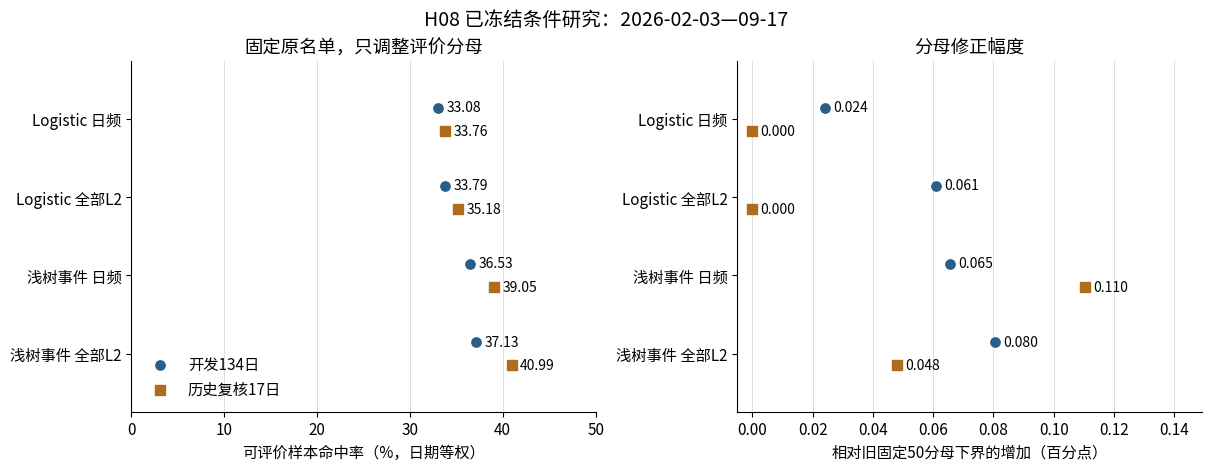

In [6]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

evaluable_font_path = Path(
    "/home/wsw/app/research-evidence/subscription-next-high-2026-09-22-mg7mzsz2/NotoSansCJKsc-Regular.otf"
)
font_manager.fontManager.addfont(str(evaluable_font_path))
evaluable_font_name = font_manager.FontProperties(
    fname=str(evaluable_font_path)
).get_name()
plt.rcParams.update(
    {"font.family": evaluable_font_name, "font.size": 11, "axes.unicode_minus": False}
)
evaluable_chart_methods = [
    "logistic__daily",
    "logistic__all",
    "hist_event__daily",
    "hist_event__all",
]
evaluable_chart_labels = [
    "Logistic 日频",
    "Logistic 全部L2",
    "浅树事件 日频",
    "浅树事件 全部L2",
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")
for stage, label, offset, color, marker in [
    ("development", "开发134日", -0.15, "#2b5d85", "o"),
    ("followup", "历史复核17日", 0.15, "#ad6d1c", "s"),
]:
    plotted = evaluable_summary.loc[stage].loc[evaluable_chart_methods]
    positions = np.arange(len(plotted)) + offset
    for ax, column, multiplier in [
        (axes[0], "precision", 100),
        (axes[1], "precision_change_pp", 1),
    ]:
        values = plotted[column].to_numpy() * multiplier
        ax.scatter(values, positions, color=color, marker=marker, label=label, s=45)
        for value, position in zip(values, positions):
            ax.annotate(
                f"{value:.3f}" if column.endswith("_pp") else f"{value:.2f}",
                (value, position),
                xytext=(6, 0),
                textcoords="offset points",
                va="center",
                fontsize=10,
            )
for ax in axes:
    ax.set_yticks(np.arange(4), evaluable_chart_labels)
    ax.invert_yaxis()
    ax.grid(axis="x", color="#dddddd", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(y=0.18)
axes[0].set_xlim(0, 50)
axes[0].set_xlabel("可评价样本命中率（%，日期等权）")
axes[0].set_title("固定原名单，只调整评价分母")
axes[1].set_xlim(-0.005, max(0.06, evaluable_summary.precision_change_pp.max() * 1.35))
axes[1].set_xlabel("相对旧固定50分母下界的增加（百分点）")
axes[1].set_title("分母修正幅度")
axes[0].legend(loc="lower left", frameon=False)
fig.suptitle("H08 已冻结条件研究：2026-02-03—09-17", fontsize=14)
fig.savefig(
    evaluable_output / "precision-denominator.png", dpi=150, bbox_inches="tight"
)
evaluable_summary.loc[(slice(None), evaluable_chart_methods), :].to_csv(
    evaluable_output / "chart-values.csv"
)
plt.show()

<a id="h08-evaluable-recovery"></a>

### 执行与解释边界

本节可以从“核对冻结输入”开始单独顺序运行，不依赖前面的训练单元。输入来自原不可变归档，
每次生成新的`subscription-evaluable-2026-09-25-*`证据目录。恢复原项目锁定环境后执行本节即可；
无需重新采集或训练。目录内保留输入哈希、逐日计数、全部方法汇总、图表、验证事实及本节执行副本。

结果只改变缺失样本的评价处理，不改变模型输入、预测、原名单或H06标签定义。
概率质量此前已经在已知标签上评价，本节没有重算或改变它。旧指标的置信包络和采用判断不沿用为新指标的结论。
严格历史接收时间仍未验证；真实成交与停牌后的持仓处理须由交易模拟单独评价，不能从条件命中率推出。

### 本次执行事实（2026-09-25）

- 六个新增代码单元已独立从头执行；原有15个训练、评价和两阶段代码单元的源码、计数与输出均保留。
- 155份输入逐文件SHA-256匹配原归档；3,775个方法日排序和名单完全一致，188,750个原入选位置
  独立连接复算通过。675个全池无缺失的方法日与旧点指标一致；当前所有方法日指标均有有效分母。
- 本次151日评价池共753,258个股票日，扣除504个未知标签后评价752,754个；开发段扣463，复核段扣41。
  这是原条件重训的预测池，**不是**使用T日最终停牌表过滤后的213日事后诊断池；两者不能混为380的同一分母。
- 浅树事件模型：开发段日频/全部L2有效入选数为6,687/6,685，剔除13/15，日均命中率36.53%/37.13%；
  历史复核有效入选数848/849，剔除2/1，命中331/348，日均命中率39.05%/40.99%。
  合并命中率另按331/848、348/849计算，见完整表，不能拿合并比值代替日期等权结果。
- 所有25种方法、两个区间的新日均命中率相对旧固定50分母下界增加0—0.111个百分点；这来自分母调整。
  未重训、未调整标签或资格，也未把原先统计检验直接当作新指标的检验。

本次归档：`/home/wsw/app/research-evidence/subscription-evaluable-2026-09-25-3m8j27r4`。`executed-evaluable.ipynb`为独立执行副本，
`daily-metrics.parquet`、`pool-summary.csv`、`summary.csv`保存精确结果，`verification.json`保存验证计数。
`before/`保留修改前工作树文件，`source.tar`绑定执行时项目代码和锁文件，`input-manifest.json`绑定输入。
首次运行的计数与指标同样通过；其图例重叠已修复，首次图和执行结果保存在
`/home/wsw/app/research-evidence/subscription-evaluable-2026-09-25-2wm4xxi8`，不覆盖该版本。
